In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from estimation_forecast_functions import DataCleaner_EUR
import holidays
from simple_strat_funcs import Clean_Implied_Vols_EUR_with_smile
from scipy.stats import norm
from hedging_strategy_class_NEW_KURT_SKEW_vega_VAR import Compare_Trading_Strategies
import seaborn as sns

/Users/alexvillamartin/Documents/MSc Diss/Code/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Global params

In [2]:
train_size = 0.7
test_size = 1 - train_size

TICKER = "EURUSD"

# always use same amount of money in USD to start and convert where necessary
IC_USD = 1_000_000 # initial capital in USD
current_rate = 1.16
NOTIONAL_USD = 1_000_000 # this is used in strategy as our notional to ensure trade positions are in domestic currency
NOTIONAL_EUR = NOTIONAL_USD / current_rate # this is used in strategy as our notional to ensure trade positions are in foreign currency

MAX_DELTA_DIFF = 500 # this param doesnt change much as our delta positions are usually much larger
SIGNAL_LB = 0.01
SIGNAL_UB = 0.99
TRANSACTION_COST_BOOL = True
TRANSACTION_COSTS_SPOT = 0.0002 / 2 # for half a leg ie selling/buying once not to enter and exit the trade
TRANSACTION_COSTS_OPTION = 0.0005 / 2 # [change to vol spreads later] for half a leg again, both in decimals

HYPERPARAM_SORT = 'sharpe_ratio' # can be 'sharpe_ratio', 'cagr', 'max_drawdown', 'total_return'
GARCH_1_2_INDICATOR = False

k_bar_MSM = 8
b_MSM = 2.0
gamma_kbar_MSM = 0.5

M = 300 # figarch lags

CONVERT_USD_INDICATOR = False # convert all portfolio values and metrics to USD for fair comparison - use when USD is not domestic

long_threshs = np.array([1.02, 1.03, 1.04, 1.05, 1.06, 1.07,  1.08, 1.09, 1.10, 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19, 1.20, 1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27])
short_threshs = np.array([0.98, 0.97, 0.96, 0.95, 0.94, 0.93, 0.92,  0.91, 0.90, 0.89, 0.88, 0.87, 0.86, 0.85, 0.84, 0.83, 0.82, 0.81, 0.80, 0.79, 0.78, 0.77, 0.76, 0.75, 0.74, 0.73])
sig_multipliers = np.array([1, 3, 5, 7, 9, 11, 13, 15, 17, 20])


# Global data

In [3]:
eurusd_5m = pd.read_parquet("EUR_USD_5M.parquet").copy()[['c']]
eurusd_5m.rename(columns={'c': 'spot'}, inplace=True)  
cleaner_eurusd = DataCleaner_EUR(eurusd_5m, start_hr=6, end_hr=18, unit_test=False) 
realised_variance_eurusd = cleaner_eurusd.clean_data()
daily_log_returns_eurusd = pd.read_parquet("DF_D_EURUSD.parquet")['Log_r']
start_date = pd.to_datetime(realised_variance_eurusd.index.min())
end_date = pd.to_datetime(realised_variance_eurusd.index.max())
spot_curr = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_EURUSD.parquet")
overnight_domestic_rate = pd.read_csv("/Users/alexvillamartin/Documents/MSc Diss/Code/SOFR_daily.csv").set_index("date")
overnight_domestic_rate.index = (pd.to_datetime(overnight_domestic_rate.index, format='mixed').normalize())
overnight_foreign_rate = pd.read_csv("estr_daily.csv").set_index("Date")

# Global functions

Change holidays where needed. 

In [4]:
def align_spots(df, aligned_df, start, end):

    df = df[(df.index >= start) & (df.index <= end)]

    years = range(start.year, end.year + 1)

    first = holidays.US(years=years)
    second = holidays.XECB(years=years)

    hols = pd.to_datetime(list(set(first) | set(second))).normalize()

    idx  = df.index
    mask = ~idx.isin(hols)
    new_df = df.loc[mask]

    df_aligned_dates = aligned_df.index
    common_dates = new_df.index.intersection(df_aligned_dates)
    new_df = new_df.loc[common_dates]

    return new_df

def sort_rates(r_b, r_t, overn_r, aligned_df, overn_for_r):

    r_b.index = pd.to_datetime(r_b.index)
    valid_mask = ~( 
                   r_t.index.isna())
    r_t_clean = r_t[valid_mask]
    r_t_clean.index = pd.to_datetime(r_t_clean.index, format='%Y-%m-%d')
    
    valid_mask2 = ~(
                   overn_r.index.isna())
    overn_r_clean = overn_r[valid_mask2]
    overn_r_clean.index = pd.to_datetime(overn_r_clean.index, format='%Y-%m-%d')

    valid_mask3 = ~(
                   overn_for_r.index.isna())
    overn_for_r_clean = overn_for_r[valid_mask3]
    overn_for_r_clean.index = pd.to_datetime(overn_for_r_clean.index, format='mixed').normalize()    

    r_b = r_b.reindex(aligned_df.index)
    r_t_clean = r_t_clean.reindex(aligned_df.index)
    overn_r_clean = overn_r_clean.reindex(aligned_df.index)
    overn_for_r_clean = overn_for_r_clean.reindex(aligned_df.index)

    r_b = r_b.ffill()
    r_t_clean = r_t_clean.ffill()
    overn_r_clean = overn_r_clean.ffill()
    overn_for_r_clean = overn_for_r_clean.ffill()

    # convert into decimals and continously compunded versions for BSE
    r_b = pd.to_numeric(r_b['rate_pct'], errors='coerce')
    r_t_clean = pd.to_numeric(r_t_clean['rate_pct'], errors='coerce')
    overn_r_clean = pd.to_numeric(overn_r_clean['value'], errors='coerce')
    r_b = r_b / 100
    r_t_clean = r_t_clean / 100
    overn_r_clean = overn_r_clean / 100 # not continously compounded
    overn_r_clean *= 1/365 # daily

    overn_for_r_clean = pd.to_numeric(overn_for_r_clean['rate_pct'], errors='coerce')
    overn_for_r_clean = overn_for_r_clean / 100 # not continously compounded
    overn_for_r_clean *= 1/365 # daily

    r_b = np.log(1 + r_b)
    r_t_clean = np.log(1 + r_t_clean)

    return r_b, r_t_clean, overn_r_clean, overn_for_r_clean

# H=30, T=1Mo

In [5]:
OPTION_MATURITY_1 = 1 / 12
H_1 = 30 

implied_vol_data_1 = pd.read_excel('/Users/alexvillamartin/Documents/MSc Diss/Code/EURUSD_1MO_ATM_D.xlsx')
vol_smile_data_1 = pd.read_csv("eurusd_vol_smile_1mo_extra.csv").set_index("CalculationDate")
Data_clean_1 = Clean_Implied_Vols_EUR_with_smile(data=implied_vol_data_1, 
                                start_date=start_date, 
                                end_date=end_date, 
                                align_df1=realised_variance_eurusd, 
                                align_df2=daily_log_returns_eurusd, 
                                smile_df=vol_smile_data_1)
implied_vol_data_1, realised_variance_1, daily_log_returns_1, vol_smile_data_1 = Data_clean_1.get_clean_data()

N_1 = len(daily_log_returns_1)
test_align_1 = daily_log_returns_1.iloc[N_1//2:-H_1]
spot_curr_test_1 = align_spots(spot_curr, test_align_1, start_date, end_date)

r_b_1 = pd.read_csv("estr_1mo_compounded.csv").set_index("Date")
r_t_1 = pd.read_csv("/Users/alexvillamartin/Documents/MSc Diss/Code/SOFR_1mo_compounded.csv").set_index("date")[['rate_pct']]

r_b_test_1, r_t_test_1, overn_dom_r_test_1, overn_for_r_test_1= sort_rates(r_b_1, r_t_1, overnight_domestic_rate, test_align_1, overnight_foreign_rate) 
r_b_test_1.ffill(inplace=True)

Estimated parameters: m0=1.210864e+00, sigma_bar=4.854110e-01
Final log-likelihood: -8.041643e+02
Estimated parameters: m0=1.195292e+00, sigma_bar=4.820609e-01
Final log-likelihood: -1.353890e+03


[I 2025-08-26 10:38:41,270] A new study created in memory with name: no-name-fed451b9-51a3-4ef8-be84-7555362cb31a
[I 2025-08-26 10:38:41,769] Trial 0 finished with value: 1.5604186020561963 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.5604186020561963.
[I 2025-08-26 10:38:42,302] Trial 1 finished with value: 1.285190063720567 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 1.5604186020561963.
[I 2025-08-26 10:38:42,705] Trial 2 finished with value: 1.5376107238251235 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: 1.5604186020561963.
[I 2025-08-26 10:38:43,086] Trial 3 finished with value: 1.8409895207886828 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 3 with value: 1.8409895207886828.
[I 2025-08-26 10:38:43,89

Estimated parameters: omega=0.0009705549253154421, alpha=0.0378, beta=0.9598
Estimated parameters: omega=0.004347417273070562, alpha=0.0455, beta=0.9443


[I 2025-08-26 10:44:20,474] A new study created in memory with name: no-name-2dae20e5-ec15-4648-b392-80e68371c24b
[I 2025-08-26 10:44:20,927] Trial 0 finished with value: 1.246315680322915 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.246315680322915.
[I 2025-08-26 10:44:21,395] Trial 1 finished with value: 1.0002659200124029 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 1.246315680322915.
[I 2025-08-26 10:44:21,791] Trial 2 finished with value: 1.0784921622489159 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: 1.246315680322915.
[I 2025-08-26 10:44:22,058] Trial 3 finished with value: 1.9025152607918925 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 3 with value: 1.9025152607918925.
[I 2025-08-26 10:44:22,730] 

Estimated parameters: omega=0.04783632598877084, d=0.2740, beta=0.2590
Final log-likelihood = 598.9679
Estimated parameters: omega=0.04385120158229892, d=0.2734, beta=0.2606
Final log-likelihood = 1046.2372


[I 2025-08-26 10:50:23,399] A new study created in memory with name: no-name-dee5d19a-2e7b-4c41-a0b5-65858be00b28
[I 2025-08-26 10:50:24,397] Trial 0 finished with value: 1.5502777437478275 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.5502777437478275.
[I 2025-08-26 10:50:25,041] Trial 1 finished with value: 1.0002465209583884 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 1.5502777437478275.
[I 2025-08-26 10:50:25,601] Trial 2 finished with value: 0.8349844241982257 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: 1.5502777437478275.
[I 2025-08-26 10:50:26,071] Trial 3 finished with value: 1.4778376025051112 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 0 with value: 1.5502777437478275.
[I 2025-08-26 10:50:27,0

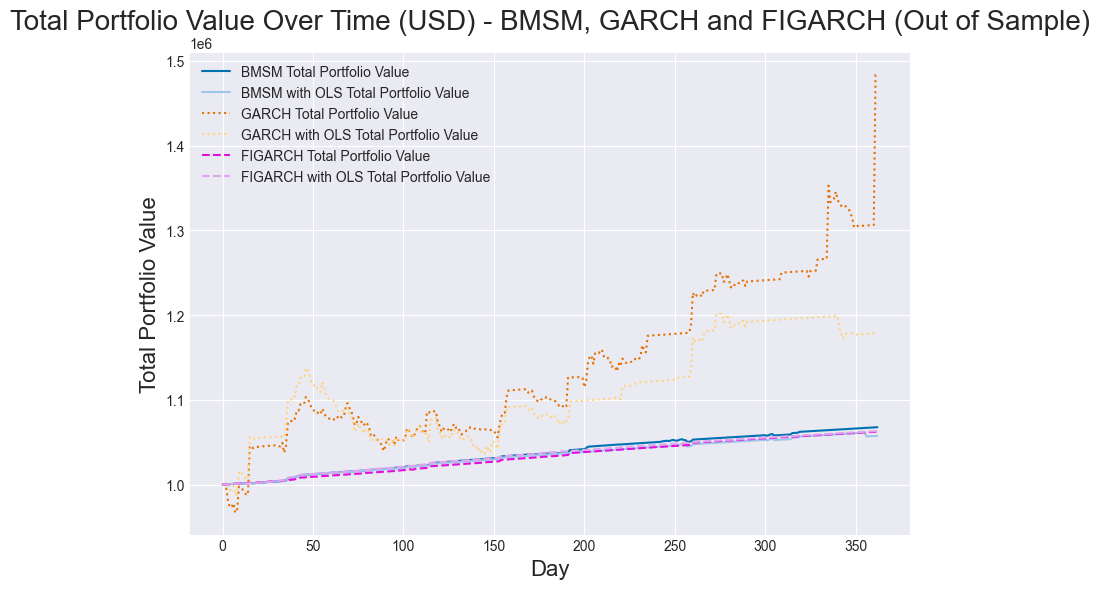

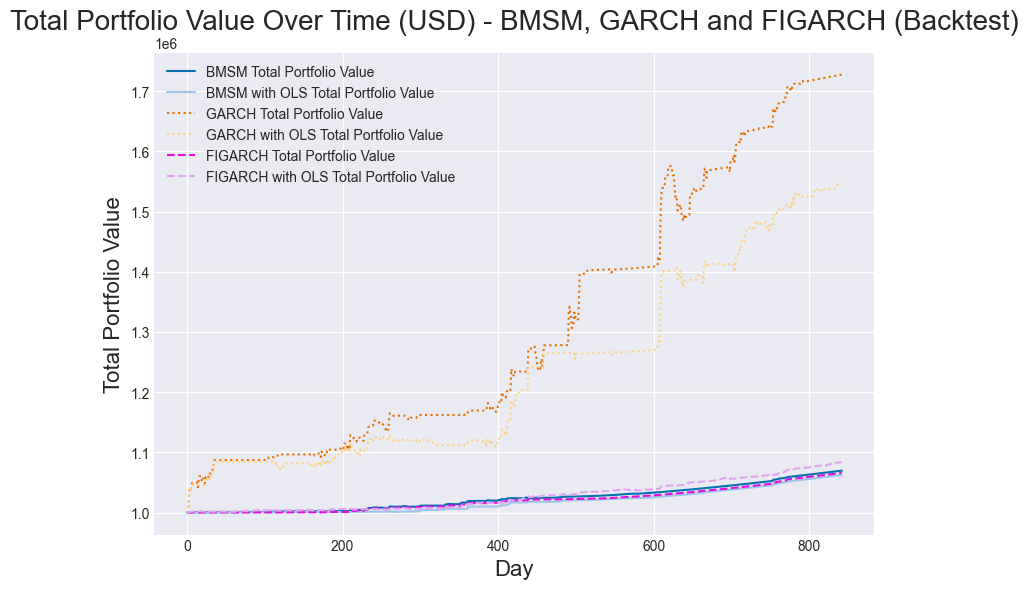

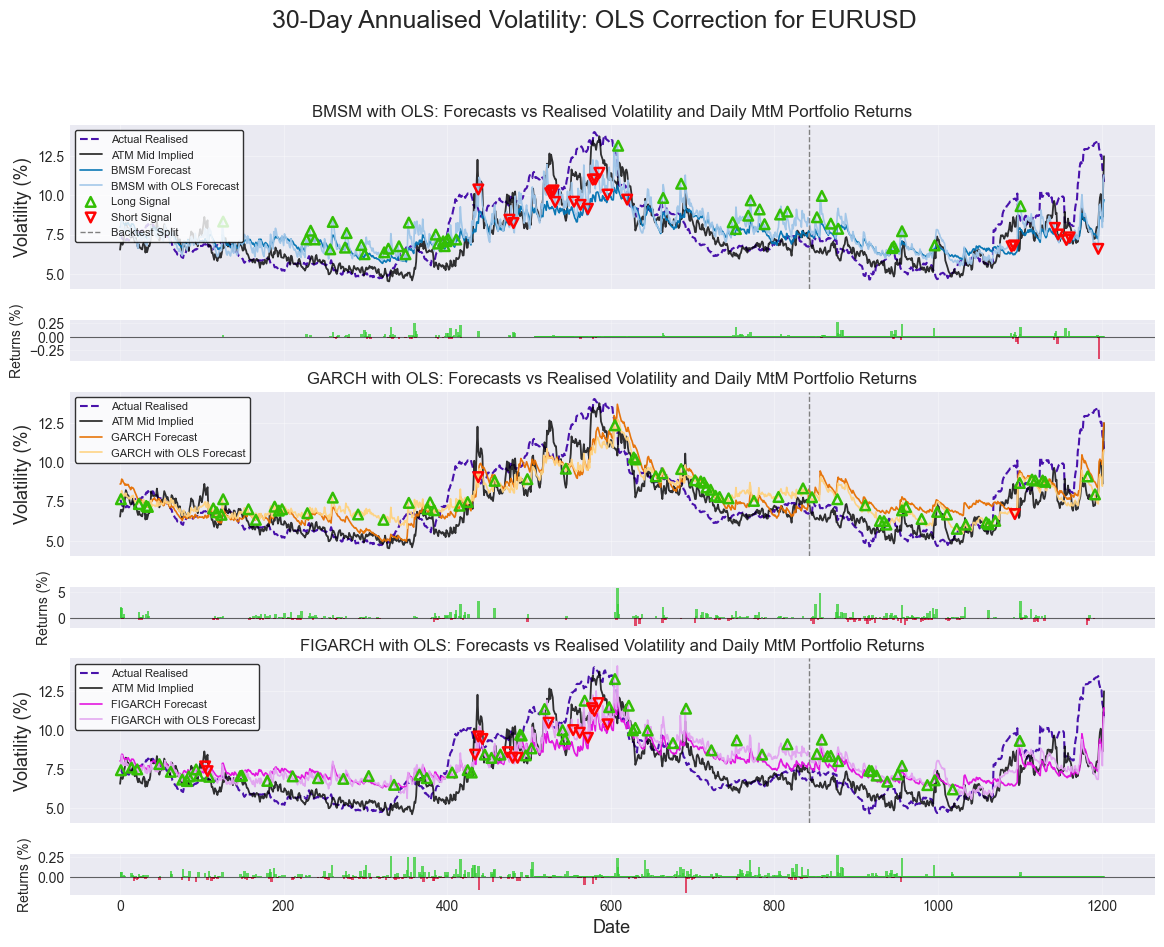

In [6]:
strategy_1 = Compare_Trading_Strategies(
    return_series=daily_log_returns_1, 
    realised_variance_series=realised_variance_1,
    atm_implied_vol_data=implied_vol_data_1,
    vol_smile_data=vol_smile_data_1,
    train_size=train_size,
    ticker=TICKER,
    initial_capital_domestic=IC_USD,
    notional_base=NOTIONAL_EUR,
    maximum_delta_difference=MAX_DELTA_DIFF,
    signal_lb=SIGNAL_LB,
    signal_ub=SIGNAL_UB,
    transaction_cost_indicator=TRANSACTION_COST_BOOL,
    transaction_costs_spot=TRANSACTION_COSTS_SPOT,
    transaction_costs_option=TRANSACTION_COSTS_OPTION,
    option_maturity=OPTION_MATURITY_1,
    forecast_horizon=H_1,
    spot_series=spot_curr_test_1,
    overnight_domestic_rate=overn_dom_r_test_1,
    overnight_foreign_rate=overn_for_r_test_1,
    domestic_rate=r_t_test_1,
    foreign_rate=r_b_test_1, 
    plots = False, 
    verbose=False, 
    sort_hyperparams_by=HYPERPARAM_SORT, 
    garch_1_2_indicator=GARCH_1_2_INDICATOR, 
    kbar=k_bar_MSM,
    b=b_MSM,
    gamma_kbar=gamma_kbar_MSM,
    convert_USD=CONVERT_USD_INDICATOR, 
    M = M, 
    long_thresholds=long_threshs,
    short_thresholds=short_threshs,
    sig_multipliers=sig_multipliers)

df_1_new = strategy_1.compare_strategies(False)


Estimated parameters: m0=1.210864e+00, sigma_bar=4.854110e-01
Final log-likelihood: -8.041643e+02
Estimated parameters: m0=1.195292e+00, sigma_bar=4.820609e-01
Final log-likelihood: -1.353890e+03


[I 2025-09-03 16:45:51,403] A new study created in memory with name: no-name-21ac1ddc-fd02-4987-b012-a5da20c87efb
[I 2025-09-03 16:45:52,053] Trial 0 finished with value: 1.408641948133474 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.408641948133474.
[I 2025-09-03 16:45:52,792] Trial 1 finished with value: 0.8535565580234545 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 1.408641948133474.
[I 2025-09-03 16:45:53,437] Trial 2 finished with value: 1.2624856124271477 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: 1.408641948133474.
[I 2025-09-03 16:45:54,045] Trial 3 finished with value: 1.394586621407727 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 0 with value: 1.408641948133474.
[I 2025-09-03 16:45:54,814] Tr

Estimated parameters: omega=0.0009705549253154421, alpha=0.0378, beta=0.9598
Estimated parameters: omega=0.004347417273070562, alpha=0.0455, beta=0.9443


[I 2025-09-03 16:53:38,062] A new study created in memory with name: no-name-a68d0580-40bc-4124-aff0-1b4668e6aa02
[I 2025-09-03 16:53:38,714] Trial 0 finished with value: 1.8493548049713835 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.8493548049713835.
[I 2025-09-03 16:53:39,392] Trial 1 finished with value: 1.4837751914313826 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 1.8493548049713835.
[I 2025-09-03 16:53:39,998] Trial 2 finished with value: 2.0245806816489003 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 2 with value: 2.0245806816489003.
[I 2025-09-03 16:53:40,608] Trial 3 finished with value: 1.883189810879704 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 2 with value: 2.0245806816489003.
[I 2025-09-03 16:53:41,40

Estimated parameters: omega=0.04783632598877084, d=0.2740, beta=0.2590
Final log-likelihood = 598.9679
Estimated parameters: omega=0.04385120158229892, d=0.2734, beta=0.2606
Final log-likelihood = 1046.2372


[I 2025-09-03 17:01:49,003] A new study created in memory with name: no-name-57751a45-a97e-47af-831f-0725f6236af9
[I 2025-09-03 17:01:49,774] Trial 0 finished with value: 1.261289933173367 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.261289933173367.
[I 2025-09-03 17:01:50,546] Trial 1 finished with value: 1.054992357367761 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 1.261289933173367.
[I 2025-09-03 17:01:51,229] Trial 2 finished with value: 1.2797034519002808 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 2 with value: 1.2797034519002808.
[I 2025-09-03 17:01:51,890] Trial 3 finished with value: 1.5012702526640298 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 3 with value: 1.5012702526640298.
[I 2025-09-03 17:01:52,693] 

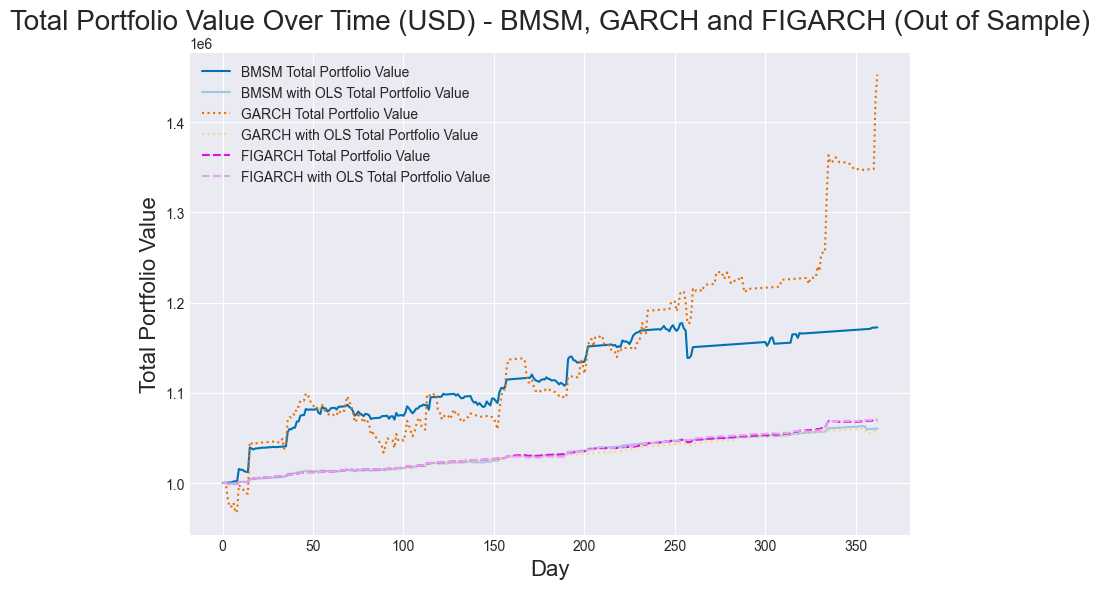

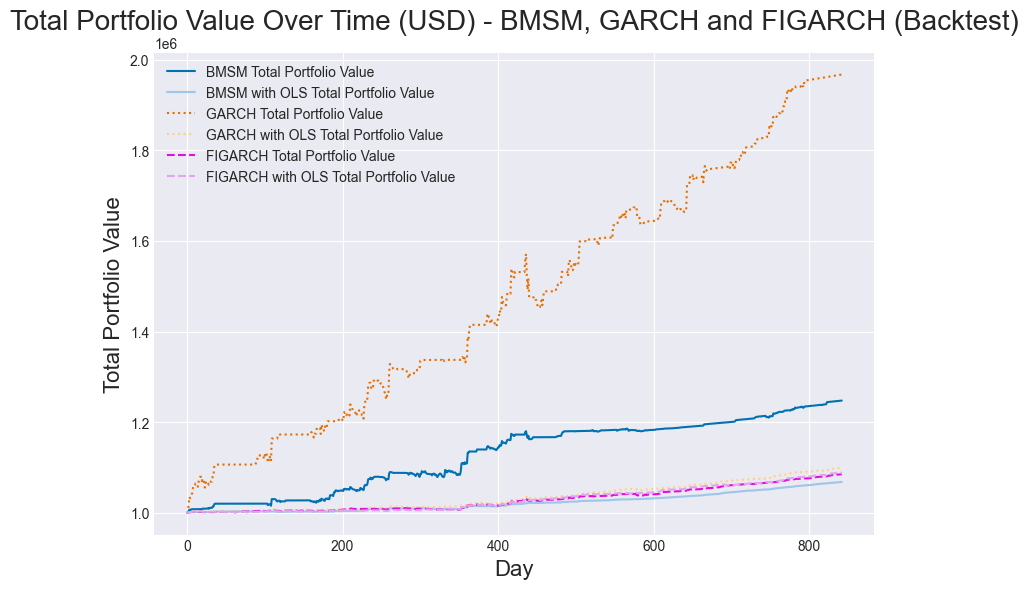

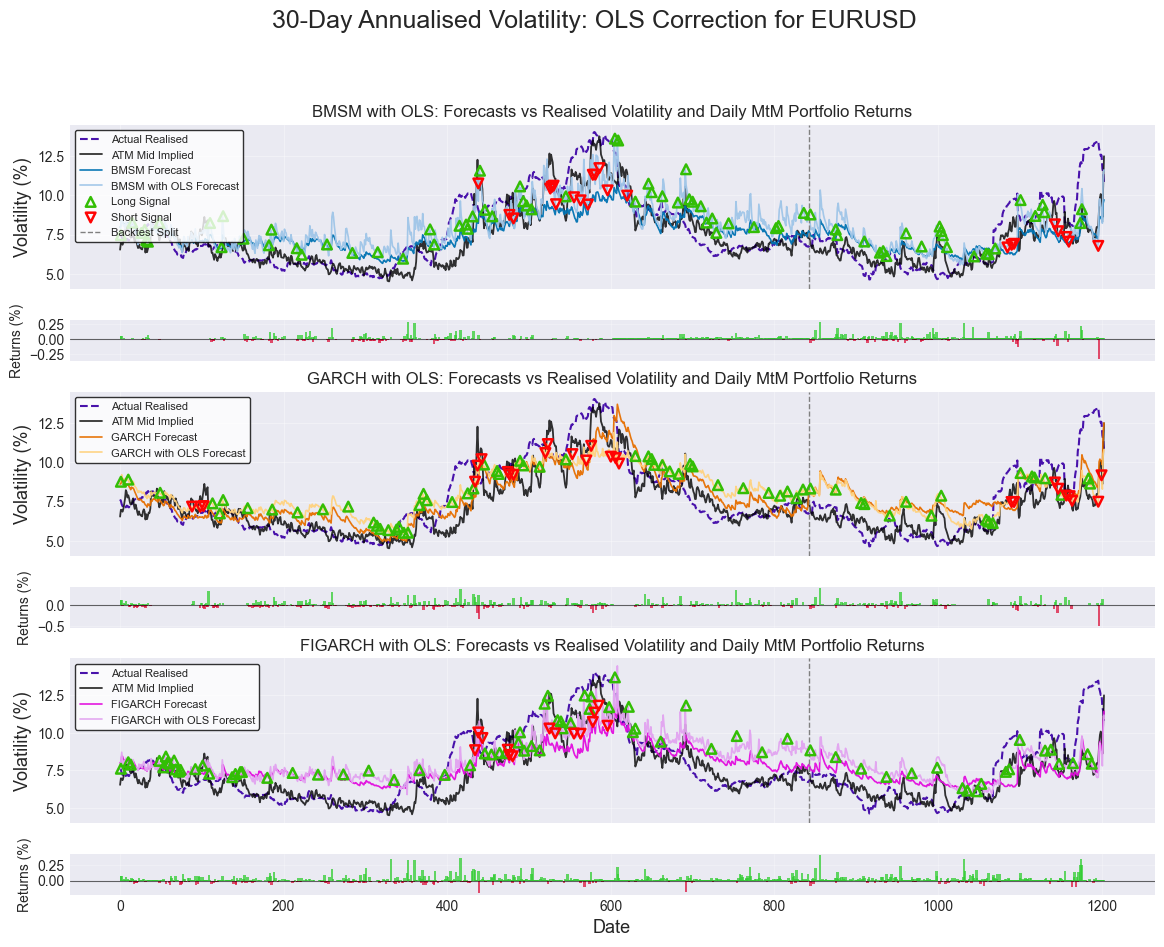

In [6]:
strategy_1 = Compare_Trading_Strategies(
    return_series=daily_log_returns_1, 
    realised_variance_series=realised_variance_1,
    atm_implied_vol_data=implied_vol_data_1,
    vol_smile_data=vol_smile_data_1,
    train_size=train_size,
    ticker=TICKER,
    initial_capital_domestic=IC_USD,
    notional_base=NOTIONAL_EUR,
    maximum_delta_difference=MAX_DELTA_DIFF,
    signal_lb=SIGNAL_LB,
    signal_ub=SIGNAL_UB,
    transaction_cost_indicator=TRANSACTION_COST_BOOL,
    transaction_costs_spot=TRANSACTION_COSTS_SPOT,
    transaction_costs_option=TRANSACTION_COSTS_OPTION,
    option_maturity=OPTION_MATURITY_1,
    forecast_horizon=H_1,
    spot_series=spot_curr_test_1,
    overnight_domestic_rate=overn_dom_r_test_1,
    overnight_foreign_rate=overn_for_r_test_1,
    domestic_rate=r_t_test_1,
    foreign_rate=r_b_test_1, 
    plots = False, 
    verbose=False, 
    sort_hyperparams_by=HYPERPARAM_SORT, 
    garch_1_2_indicator=GARCH_1_2_INDICATOR, 
    kbar=k_bar_MSM,
    b=b_MSM,
    gamma_kbar=gamma_kbar_MSM,
    convert_USD=CONVERT_USD_INDICATOR, 
    M = M, 
    long_thresholds=long_threshs,
    short_thresholds=short_threshs,
    sig_multipliers=sig_multipliers)

df_1_new = strategy_1.compare_strategies(False)


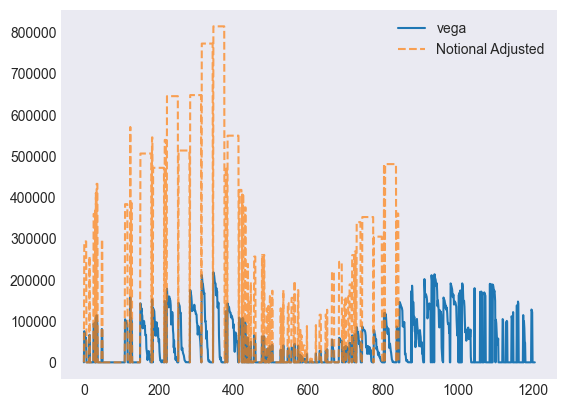

In [7]:
plt.plot(np.hstack((strategy_1.vega_bmsm_bt_ols,strategy_1.vega_bmsm_oos_ols)), label = 'vega')
plt.plot(strategy_1.trading_summary_bmsm_bt_ols['Notional Adjusted'], label = 'Notional Adjusted', linestyle = '--', alpha = 0.7)
plt.legend()

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_37018/2988861414.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(strategy_1.vega_bmsm_bt_ols / strategy_1.trading_summary_bmsm_bt_ols['Notional Adjusted'], label = 'vega')


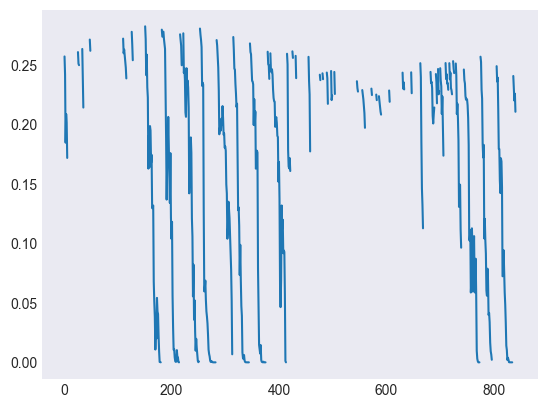

In [34]:
plt.plot(strategy_1.vega_bmsm_bt_ols / strategy_1.trading_summary_bmsm_bt_ols['Notional Adjusted'], label = 'vega')

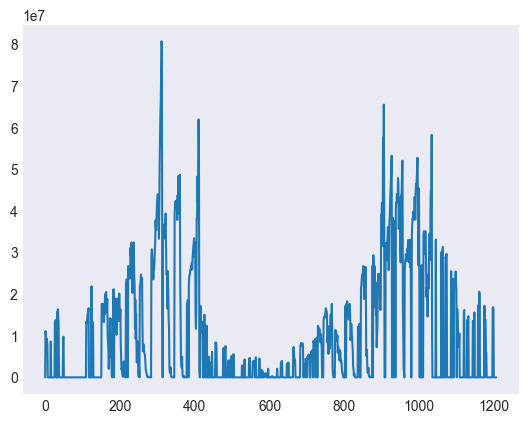

In [8]:
plt.plot(np.hstack((strategy_1.gamma_bmsm_bt_ols,strategy_1.gamma_bmsm_oos_ols)), label = 'gamma')

In [187]:
option_positions_bt = strategy_1.trading_summary_bmsm_bt['Option Positions'][1:]
option_positions_oos = strategy_1.trading_summary_bmsm_oos['Option Positions'][1:]

d_sig_bt_1 = np.diff(strategy_1.atm_mid_implied_vol_backtest)
d_sig_oos_1 = np.diff(strategy_1.atm_mid_implied_vol_oos)

term1_bt = strategy_1.vega_bmsm_bt_ols[1:-1] * d_sig_bt_1 * option_positions_bt[:-1]
term1_oos = strategy_1.vega_bmsm_oos_ols[1:-1] * d_sig_oos_1 * option_positions_oos[:-1]


term1 = np.hstack((term1_bt, term1_oos))


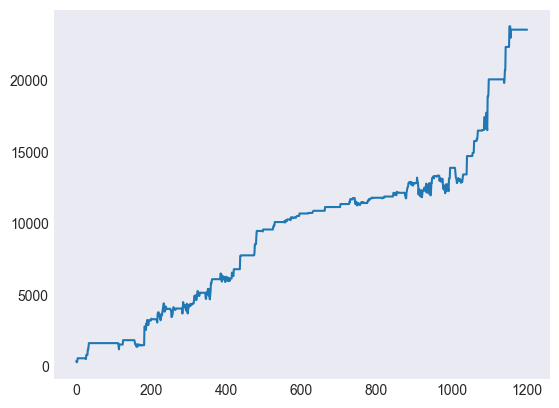

In [189]:
plt.plot(term1.cumsum(), label="Vega Term")

In [7]:
error_metrics_df_1 = strategy_1.get_statistical_error_metrics_for_all() # for H=30, T=30 options EURUSD

In [8]:
error_metrics_df_1

,Norm MSE,DM Test Stat MSE,DM p-value (one-sided) MSE,Norm MAE,DM Test Stat MAE,DM p-value (one-sided) MAE
BMSM,0.545579,NaN,NaN,0.692727,NaN,NaN
BMSM OLS,0.512198,-0.668648,0.251924,0.682116,-0.316975,0.375659
GARCH,0.414251,NaN,NaN,0.613892,NaN,NaN
GARCH OLS,0.447295,0.742158,0.770932,0.637104,0.587748,0.721594
FIGARCH,0.569416,NaN,NaN,0.734450,NaN,NaN
FIGARCH OLS,0.544390,-0.536211,0.295956,0.717926,-0.496137,0.309944


In [9]:
error_metrics_df_1.to_csv("USDEUR_Errors_H_30_T_1MO_OLS.csv")

In [9]:
df_1_new

,long_threshold,short_threshold,signal_multiplier,sharpe_ratio (USD),max_drawdown (USD),calmar_ratio (USD),cagr (USD),Precision (all),Precision (active),Win/loss ratio (all),Win/loss ratio (active),Avg win (all),Avg win (active),Avg loss (all),Avg loss (active),Non-active share,Total trades
BMSM Backtest,1.25,0.75,7.00,1.84,-1.51,3.61,6.83%,0.23,0.49,2.39,1.91,0.20%,0.20%,-0.08%,-0.11%,0.53,52.00
BMSM Out of Sample,1.25,0.75,7.00,1.43,-3.29,2.32,11.68%,0.24,0.49,2.16,1.63,0.35%,0.35%,-0.16%,-0.21%,0.50,30.00
BMSM with OLS Backtest,1.22,0.78,1.00,1.90,-0.28,2.88,1.98%,0.28,0.48,2.49,1.98,0.03%,0.03%,-0.01%,-0.01%,0.42,67.00
BMSM with OLS Out of Sample,1.22,0.78,1.00,0.82,-0.34,1.79,4.15%,0.28,0.47,1.81,1.43,0.04%,0.04%,-0.02%,-0.03%,0.40,31.00
GARCH Backtest,1.22,0.76,15.00,2.26,-7.59,2.52,22.42%,0.22,0.52,2.70,1.88,0.68%,0.68%,-0.25%,-0.36%,0.59,73.00
GARCH Out of Sample,1.22,0.76,15.00,1.82,-5.98,3.77,29.60%,0.33,0.44,2.39,2.08,0.69%,0.69%,-0.29%,-0.33%,0.24,23.00
GARCH with OLS Backtest,1.25,0.90,1.00,1.96,-0.51,3.28,2.87%,0.32,0.47,2.19,1.81,0.05%,0.05%,-0.02%,-0.03%,0.32,65.00
GARCH with OLS Out of Sample,1.25,0.90,1.00,0.48,-0.51,0.85,3.96%,0.28,0.43,1.82,1.52,0.05%,0.05%,-0.03%,-0.03%,0.34,27.00
FIGARCH Backtest,1.02,0.73,1.00,1.57,-0.53,2.37,2.46%,0.37,0.46,2.03,1.77,0.04%,0.04%,-0.02%,-0.02%,0.20,53.00
FIGARCH Out of Sample,1.02,0.73,1.00,1.54,-0.26,4.60,4.77%,0.33,0.43,2.32,2.03,0.04%,0.04%,-0.02%,-0.02%,0.24,23.00


Save these models too.

In [11]:
df_1_new.data.to_csv("USDEUR_Strategy_H_30_T_1MO_OLS.csv", index=True)

In [12]:
strategy_1.model_bmsm_oos.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     18.75
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           3.78e-15
Time:                        10:58:35   Log-Likelihood:                 436.06
No. Observations:                2045   AIC:                            -862.1
Df Residuals:                    2040   BIC:                            -834.0
Df Model:                           4                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0136      0.012     -1.169      0.242      -0.036       0.009
x1             0.0848      0.030      2.868      0.004       0.027       0.143
x2            -0.0632      0.032     -2.005      0.045      -0.125      -0.001
x3            -0.0356      0.013     -2.738      0.006      -0.061      -0.010
x4            -0.0428      0.016     -2.719      0.007      -0.074      -0.012
==============================================================================
Omnibus:                      626.032   Durbin-Watson:                   0.063
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2135.704
Skew:                           1.507   Prob(JB):                         0.00
Kurtosis:                       6.998   Cond. No.                         5.58
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 7 lags and without small sample correction
"""

In [13]:
strategy_1.model_garch_oos.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.123
Method:                 Least Squares   F-statistic:                     7.287
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           7.35e-05
Time:                        10:58:41   Log-Likelihood:                 429.48
No. Observations:                2045   AIC:                            -851.0
Df Residuals:                    2041   BIC:                            -828.5
Df Model:                           3                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1177      0.012     -9.934      0.000      -0.141      -0.094
x1            -0.0221      0.012     -1.785      0.074      -0.046       0.002
x2            -0.0278      0.013     -2.187      0.029      -0.053      -0.003
x3            -0.0435      0.014     -3.120      0.002      -0.071      -0.016
==============================================================================
Omnibus:                      719.877   Durbin-Watson:                   0.045
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2965.635
Skew:                           1.672   Prob(JB):                         0.00
Kurtosis:                       7.860   Cond. No.                         2.02
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 7 lags and without small sample correction
"""

In [14]:
strategy_1.model_figarch_oos.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.144
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                     9.395
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           3.63e-06
Time:                        10:58:51   Log-Likelihood:                 300.24
No. Observations:                2045   AIC:                            -592.5
Df Residuals:                    2041   BIC:                            -570.0
Df Model:                           3                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0299      0.013     -2.385      0.017      -0.055      -0.005
x1            -0.0027      0.008     -0.336      0.737      -0.018       0.013
x2            -0.0411      0.013     -3.079      0.002      -0.067      -0.015
x3            -0.0622      0.017     -3.646      0.000      -0.096      -0.029
==============================================================================
Omnibus:                      616.063   Durbin-Watson:                   0.046
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2038.307
Skew:                           1.494   Prob(JB):                         0.00
Kurtosis:                       6.872   Cond. No.                         1.70
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 7 lags and without small sample correction
"""

# H=91, T=3MO

In [178]:
OPTION_MATURITY_2 = 3 / 12
H_2 = 91 

vol_smile_data_2 = pd.read_csv("eurusd_vol_smile_3mo_extra.csv").set_index("CalculationDate")
implied_vol_data_2 = pd.DataFrame({
    'Exchange Date': vol_smile_data_2.index, 
    "Bid": vol_smile_data_2['ATM'], 
    "Ask": vol_smile_data_2['ATM'],
    "BidNet": vol_smile_data_2['ATM']})
Data_clean_2 = Clean_Implied_Vols_EUR_with_smile(data=implied_vol_data_2, 
                                start_date=start_date, 
                                end_date=end_date, 
                                align_df1=realised_variance_eurusd, 
                                align_df2=daily_log_returns_eurusd, 
                                smile_df=vol_smile_data_2)
implied_vol_data_2, realised_variance_2, daily_log_returns_2, vol_smile_data_2 = Data_clean_2.get_clean_data()

N_2 = len(daily_log_returns_2)
test_align_2 = daily_log_returns_2.iloc[N_2//2:-H_2]
spot_curr_test_2 = align_spots(spot_curr, test_align_2, start_date, end_date)

r_b_2 = pd.read_csv("estr_3mo_compounded.csv").set_index("Date")
r_t_2 = pd.read_csv("/Users/alexvillamartin/Documents/MSc Diss/Code/SOFR_3mo_compounded.csv").set_index("date")[['rate_pct']]

r_b_test_2, r_t_test_2, overn_dom_r_test_2, overn_for_r_test_2= sort_rates(r_b_2, r_t_2, overnight_domestic_rate, test_align_2, overnight_foreign_rate) 
r_b_test_2.ffill(inplace=True)

Estimated parameters: m0=1.210864e+00, sigma_bar=4.854110e-01
Final log-likelihood: -8.041643e+02
Estimated parameters: m0=1.198027e+00, sigma_bar=4.821360e-01
Final log-likelihood: -1.327739e+03


[I 2025-09-03 20:39:40,826] A new study created in memory with name: no-name-08afb844-434a-4839-b708-2170aed4e7cc
[I 2025-09-03 20:39:41,535] Trial 0 finished with value: 1.7265928793805203 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.7265928793805203.
[I 2025-09-03 20:39:42,364] Trial 1 finished with value: 1.5506727234466646 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 1.7265928793805203.
[I 2025-09-03 20:39:43,086] Trial 2 finished with value: 2.2537621450215704 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 2 with value: 2.2537621450215704.
[I 2025-09-03 20:39:43,750] Trial 3 finished with value: 1.7840283486371349 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 2 with value: 2.2537621450215704.
[I 2025-09-03 20:39:44,5

Estimated parameters: omega=0.0009705549253154421, alpha=0.0378, beta=0.9598
Estimated parameters: omega=0.0011730197646743856, alpha=0.0401, beta=0.9564


[I 2025-09-03 20:49:13,697] A new study created in memory with name: no-name-7e02bd28-06ab-416e-81c0-198066c6a8fb
[I 2025-09-03 20:49:14,443] Trial 0 finished with value: 1.3646966900571358 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.3646966900571358.
[I 2025-09-03 20:49:15,312] Trial 1 finished with value: 1.4709851102090232 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 1 with value: 1.4709851102090232.
[I 2025-09-03 20:49:16,071] Trial 2 finished with value: 1.7552066834372428 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 2 with value: 1.7552066834372428.
[I 2025-09-03 20:49:16,847] Trial 3 finished with value: 1.695194720815295 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 2 with value: 1.7552066834372428.
[I 2025-09-03 20:49:17,67

Estimated parameters: omega=0.04783632598877084, d=0.2740, beta=0.2590
Final log-likelihood = 598.9679
Estimated parameters: omega=0.04362897957209833, d=0.2755, beta=0.2616
Final log-likelihood = 1017.4750


[I 2025-09-03 20:59:07,467] A new study created in memory with name: no-name-34652530-ad32-4dd7-bbc5-14c7d69e60af
[I 2025-09-03 20:59:08,271] Trial 0 finished with value: 1.3620918519815746 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.3620918519815746.
[I 2025-09-03 20:59:09,027] Trial 1 finished with value: 1.6259903508757896 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 1 with value: 1.6259903508757896.
[I 2025-09-03 20:59:09,802] Trial 2 finished with value: 1.8238458666364739 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 2 with value: 1.8238458666364739.
[I 2025-09-03 20:59:10,550] Trial 3 finished with value: 1.4454128123085859 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 2 with value: 1.8238458666364739.
[I 2025-09-03 20:59:11,3

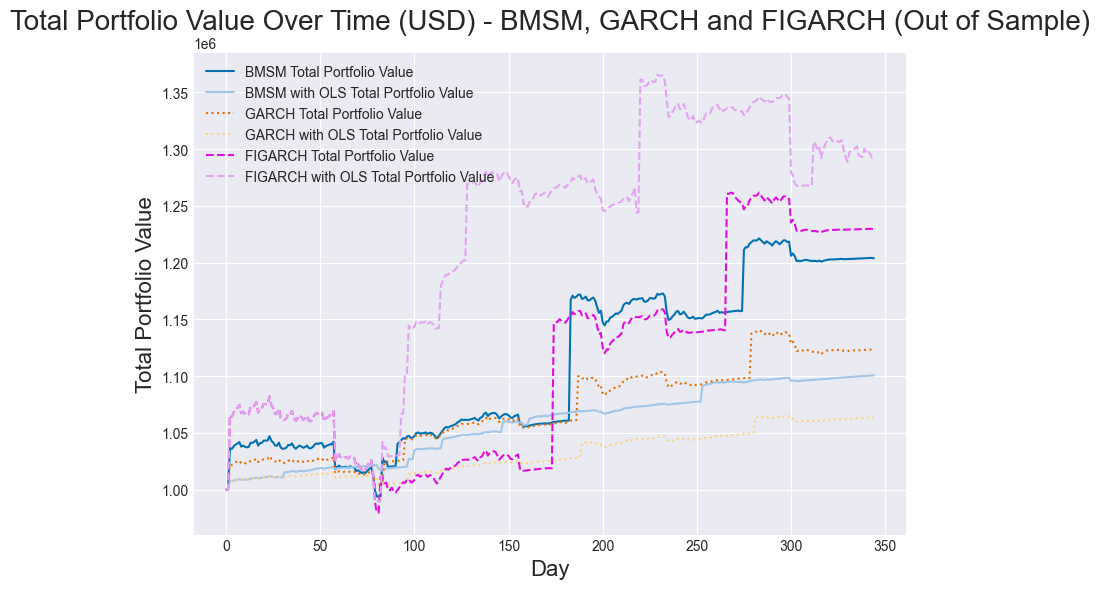

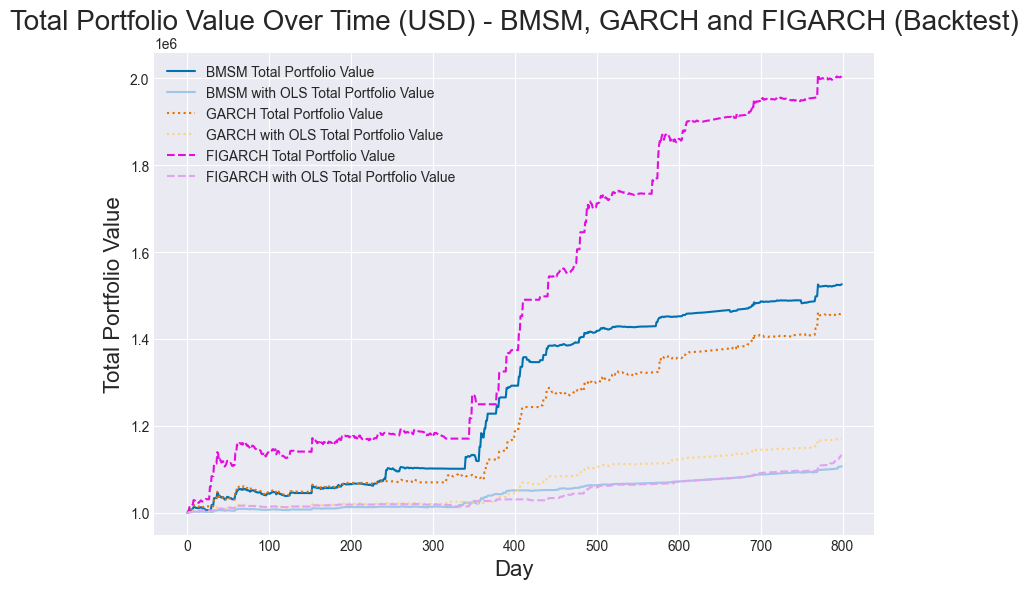

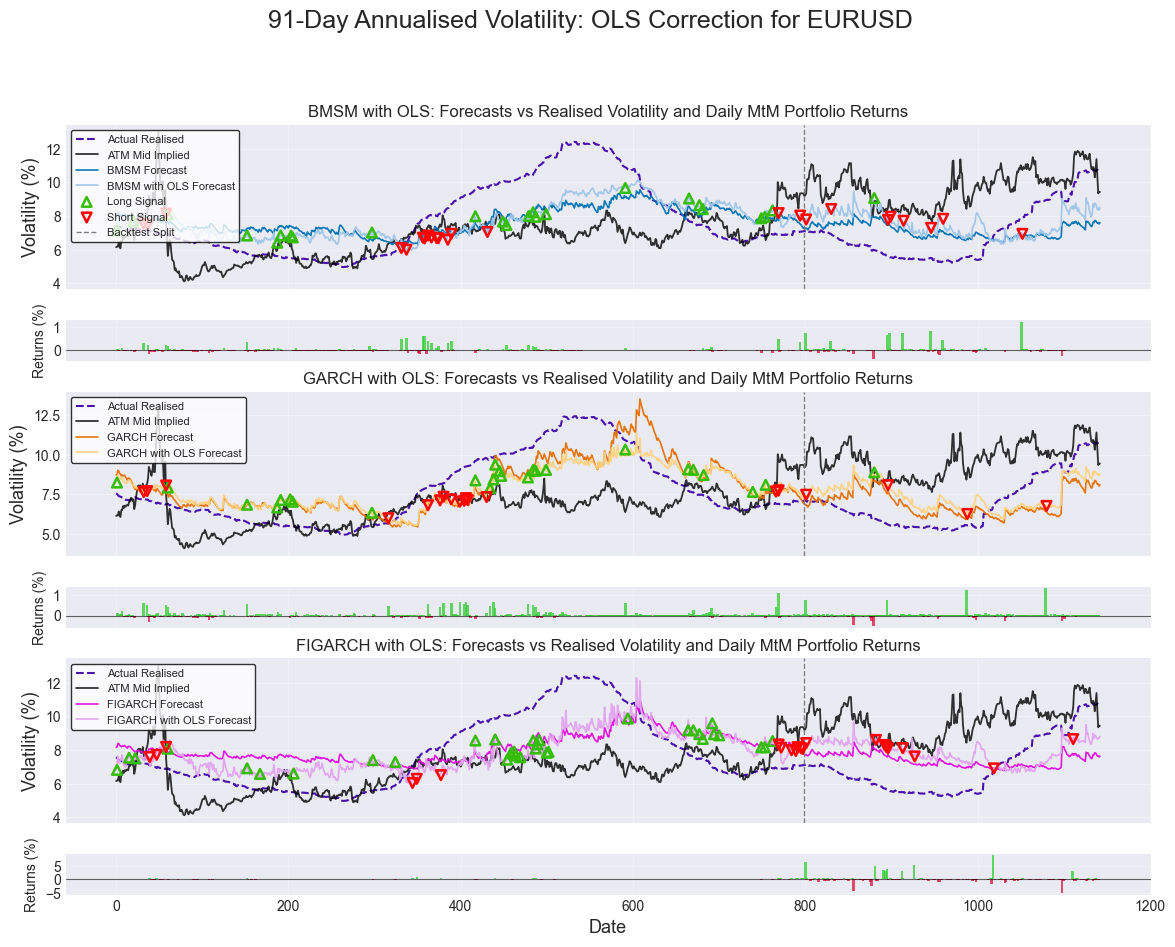

In [179]:
strategy_2 = Compare_Trading_Strategies(
    return_series=daily_log_returns_2, 
    realised_variance_series=realised_variance_2,
    atm_implied_vol_data=implied_vol_data_2,
    vol_smile_data=vol_smile_data_2,
    train_size=train_size,
    ticker=TICKER,
    initial_capital_domestic=IC_USD,
    notional_base=NOTIONAL_EUR,
    maximum_delta_difference=MAX_DELTA_DIFF,
    signal_lb=SIGNAL_LB,
    signal_ub=SIGNAL_UB,
    transaction_cost_indicator=TRANSACTION_COST_BOOL,
    transaction_costs_spot=TRANSACTION_COSTS_SPOT,
    transaction_costs_option=TRANSACTION_COSTS_OPTION,
    option_maturity=OPTION_MATURITY_2,
    forecast_horizon=H_2,
    spot_series=spot_curr_test_2,
    overnight_domestic_rate=overn_dom_r_test_2,
    overnight_foreign_rate=overn_for_r_test_2,
    domestic_rate=r_t_test_2,
    foreign_rate=r_b_test_2, 
    plots = False, 
    verbose=False, 
    sort_hyperparams_by=HYPERPARAM_SORT, 
    garch_1_2_indicator=GARCH_1_2_INDICATOR, 
    kbar=k_bar_MSM,
    b=b_MSM,
    gamma_kbar=gamma_kbar_MSM,
    convert_USD=CONVERT_USD_INDICATOR, 
    M = M, 
    long_thresholds=long_threshs,
    short_thresholds=short_threshs,
    sig_multipliers=sig_multipliers)

df_2 = strategy_2.compare_strategies(verbose = False)

In [17]:
error_metrics_df_2 = strategy_2.get_statistical_error_metrics_for_all() 

In [18]:
error_metrics_df_2

,Norm MSE,DM Test Stat MSE,DM p-value (one-sided) MSE,Norm MAE,DM Test Stat MAE,DM p-value (one-sided) MAE
BMSM,0.696337,NaN,NaN,0.846127,NaN,NaN
BMSM OLS,0.647538,-0.615228,0.269263,0.817848,-0.519413,0.301787
GARCH,0.531913,NaN,NaN,0.734150,NaN,NaN
GARCH OLS,0.603387,0.539591,0.705208,0.770022,0.394184,0.653241
FIGARCH,0.754135,NaN,NaN,0.916209,NaN,NaN
FIGARCH OLS,0.689220,-0.615435,0.269195,0.846543,-0.890810,0.186609


In [19]:
error_metrics_df_2.to_csv("USDEUR_Errors_H_91_T_3MO_OLS.csv")

In [180]:
df_2

,long_threshold,short_threshold,signal_multiplier,sharpe_ratio (USD),max_drawdown (USD),calmar_ratio (USD),cagr (USD),Precision (all),Precision (active),Win/loss ratio (all),Win/loss ratio (active),Avg win (all),Avg win (active),Avg loss (all),Avg loss (active),Non-active share,Total trades
BMSM Backtest,1.11,0.91,5.00,2.56,-1.63,7.56,14.24%,0.42,0.50,3.00,2.67,0.19%,0.19%,-0.06%,-0.07%,0.17,41.00
BMSM Out of Sample,1.11,0.91,5.00,0.93,-5.08,1.97,14.51%,0.54,0.56,1.27,1.23,0.21%,0.21%,-0.17%,-0.17%,0.03,5.00
BMSM with OLS Backtest,1.15,0.88,1.00,2.13,-0.33,6.55,3.24%,0.38,0.47,2.80,2.52,0.04%,0.04%,-0.01%,-0.02%,0.19,39.00
BMSM with OLS Out of Sample,1.15,0.88,1.00,1.78,-0.36,9.61,7.26%,0.47,0.50,2.25,2.13,0.05%,0.05%,-0.02%,-0.03%,0.08,9.00
GARCH Backtest,1.26,0.88,3.00,2.38,-2.05,5.33,12.65%,0.41,0.51,2.28,2.06,0.20%,0.20%,-0.09%,-0.10%,0.20,34.00
GARCH Out of Sample,1.26,0.88,3.00,0.87,-2.46,2.01,8.86%,0.55,0.57,1.07,1.03,0.13%,0.13%,-0.12%,-0.12%,0.05,5.00
GARCH with OLS Backtest,1.23,0.94,1.00,2.33,-0.70,5.60,5.08%,0.39,0.48,2.58,2.32,0.07%,0.07%,-0.03%,-0.03%,0.18,39.00
GARCH with OLS Out of Sample,1.23,0.94,1.00,0.48,-1.07,0.89,4.61%,0.53,0.56,0.97,0.93,0.04%,0.04%,-0.04%,-0.04%,0.06,5.00
FIGARCH Backtest,1.26,0.98,9.00,2.68,-3.12,6.71,24.51%,0.39,0.49,2.91,2.61,0.35%,0.35%,-0.12%,-0.13%,0.21,37.00
FIGARCH Out of Sample,1.26,0.98,9.00,0.73,-9.47,1.22,16.27%,0.51,0.51,1.35,1.32,0.31%,0.31%,-0.23%,-0.24%,0.01,4.00


In [21]:
df_2.data.to_csv("USDEUR_Strategy_H_91_T_3MO.csv", index=True)

In [22]:
strategy_2.model_bmsm_oos.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     15.02
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           4.30e-12
Time:                        11:27:12   Log-Likelihood:                 447.47
No. Observations:                1941   AIC:                            -884.9
Df Residuals:                    1936   BIC:                            -857.1
Df Model:                           4                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        5.44e-05      0.012      0.004      0.996      -0.024       0.024
x1             0.0764      0.029      2.648      0.008       0.020       0.133
x2            -0.0652      0.030     -2.203      0.028      -0.123      -0.007
x3            -0.0362      0.013     -2.754      0.006      -0.062      -0.010
x4            -0.0411      0.015     -2.744      0.006      -0.070      -0.012
==============================================================================
Omnibus:                      123.235   Durbin-Watson:                   0.023
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              147.867
Skew:                           0.628   Prob(JB):                     7.78e-33
Kurtosis:                       3.499   Cond. No.                         7.16
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 7 lags and without small sample correction
"""

In [23]:
strategy_2.model_garch_oos.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.098
Method:                 Least Squares   F-statistic:                     12.44
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           4.68e-08
Time:                        11:27:18   Log-Likelihood:                 447.24
No. Observations:                1941   AIC:                            -886.5
Df Residuals:                    1937   BIC:                            -864.2
Df Model:                           3                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0274      0.012     -2.260      0.024      -0.051      -0.004
x1             0.0860      0.017      4.960      0.000       0.052       0.120
x2            -0.0277      0.013     -2.193      0.028      -0.052      -0.003
x3            -0.0539      0.015     -3.533      0.000      -0.084      -0.024
==============================================================================
Omnibus:                       88.131   Durbin-Watson:                   0.031
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               99.243
Skew:                           0.547   Prob(JB):                     2.82e-22
Kurtosis:                       3.173   Cond. No.                         2.50
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 7 lags and without small sample correction
"""

In [24]:
strategy_2.model_figarch_oos.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.145
Method:                 Least Squares   F-statistic:                     10.50
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           7.55e-07
Time:                        11:27:23   Log-Likelihood:                 373.26
No. Observations:                1941   AIC:                            -738.5
Df Residuals:                    1937   BIC:                            -716.2
Df Model:                           3                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0250      0.013     -1.982      0.047      -0.050      -0.000
x1            -0.0216      0.009     -2.356      0.018      -0.040      -0.004
x2            -0.0402      0.014     -2.853      0.004      -0.068      -0.013
x3            -0.0600      0.015     -3.884      0.000      -0.090      -0.030
==============================================================================
Omnibus:                      108.029   Durbin-Watson:                   0.024
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              126.228
Skew:                           0.588   Prob(JB):                     3.89e-28
Kurtosis:                       3.421   Cond. No.                         2.12
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 7 lags and without small sample correction
"""

# H=182, T=6MO

In [5]:
OPTION_MATURITY_3 = 6 / 12
H_3 = 182

vol_smile_data_3 = pd.read_csv("eurusd_vol_smile_6mo_extra.csv").set_index("CalculationDate")
implied_vol_data_3 = pd.DataFrame({
    'Exchange Date': vol_smile_data_3.index, 
    "Bid": vol_smile_data_3['ATM'], 
    "Ask": vol_smile_data_3['ATM'],
    "BidNet": vol_smile_data_3['ATM']})
Data_clean_3 = Clean_Implied_Vols_EUR_with_smile(data=implied_vol_data_3, 
                                start_date=start_date, 
                                end_date=end_date, 
                                align_df1=realised_variance_eurusd, 
                                align_df2=daily_log_returns_eurusd, 
                                smile_df=vol_smile_data_3)
implied_vol_data_3, realised_variance_3, daily_log_returns_3, vol_smile_data_3 = Data_clean_3.get_clean_data()

N_3 = len(daily_log_returns_3)
test_align_3 = daily_log_returns_3.iloc[N_3//2:-H_3]
spot_curr_test_3 = align_spots(spot_curr, test_align_3, start_date, end_date)

r_b_3 = pd.read_csv("estr_6mo_compounded.csv").set_index("Date")
r_t_3 = pd.read_csv("/Users/alexvillamartin/Documents/MSc Diss/Code/SOFR_6mo_compounded.csv").set_index("date")[['rate_pct']]

r_b_test_3, r_t_test_3, overn_dom_r_test_3, overn_for_r_test_3= sort_rates(r_b_3, r_t_3, overnight_domestic_rate, test_align_3, overnight_foreign_rate) 
r_b_test_3.ffill(inplace=True)

Estimated parameters: m0=1.210864e+00, sigma_bar=4.854110e-01
Final log-likelihood: -8.041643e+02
Estimated parameters: m0=1.199194e+00, sigma_bar=4.851642e-01
Final log-likelihood: -1.292050e+03


[I 2025-09-04 13:36:06,365] A new study created in memory with name: no-name-9ce3b04c-e6ce-488c-a6ab-a02b9cd41451
[I 2025-09-04 13:36:07,003] Trial 0 finished with value: 1.7054091048109372 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.7054091048109372.
[I 2025-09-04 13:36:07,674] Trial 1 finished with value: 1.546317209049575 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 1.7054091048109372.
[I 2025-09-04 13:36:08,285] Trial 2 finished with value: 2.0065782246189343 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 2 with value: 2.0065782246189343.
[I 2025-09-04 13:36:08,876] Trial 3 finished with value: 0.9677269836298715 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 2 with value: 2.0065782246189343.
[I 2025-09-04 13:36:09,57

Estimated parameters: omega=0.0009705549253154421, alpha=0.0378, beta=0.9598
Estimated parameters: omega=0.0011646355172409558, alpha=0.0403, beta=0.9564


[I 2025-09-04 13:43:54,043] A new study created in memory with name: no-name-2da8e6ab-a046-4474-b6e1-d61459e99bf5
[I 2025-09-04 13:43:54,775] Trial 0 finished with value: 1.3133932639371908 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.3133932639371908.
[I 2025-09-04 13:43:55,553] Trial 1 finished with value: 1.2196790107149234 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 1.3133932639371908.
[I 2025-09-04 13:43:56,316] Trial 2 finished with value: 1.5765090593774833 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 2 with value: 1.5765090593774833.
[I 2025-09-04 13:43:56,973] Trial 3 finished with value: 0.4261367254117214 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 2 with value: 1.5765090593774833.
[I 2025-09-04 13:43:57,7

Estimated parameters: omega=0.04783632598877084, d=0.2740, beta=0.2590
Final log-likelihood = 598.9679
Estimated parameters: omega=0.04355291536306382, d=0.2798, beta=0.2660
Final log-likelihood = 972.5349


[I 2025-09-04 13:52:48,823] A new study created in memory with name: no-name-d9c396e9-3725-40a5-b661-86531812b9be
[I 2025-09-04 13:52:49,540] Trial 0 finished with value: 0.46683504890182376 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.46683504890182376.
[I 2025-09-04 13:52:50,243] Trial 1 finished with value: 0.6873042493577562 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 1 with value: 0.6873042493577562.
[I 2025-09-04 13:52:50,904] Trial 2 finished with value: 1.1220743759635152 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 2 with value: 1.1220743759635152.
[I 2025-09-04 13:52:51,599] Trial 3 finished with value: 0.5317527768871199 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 2 with value: 1.1220743759635152.
[I 2025-09-04 13:52:52

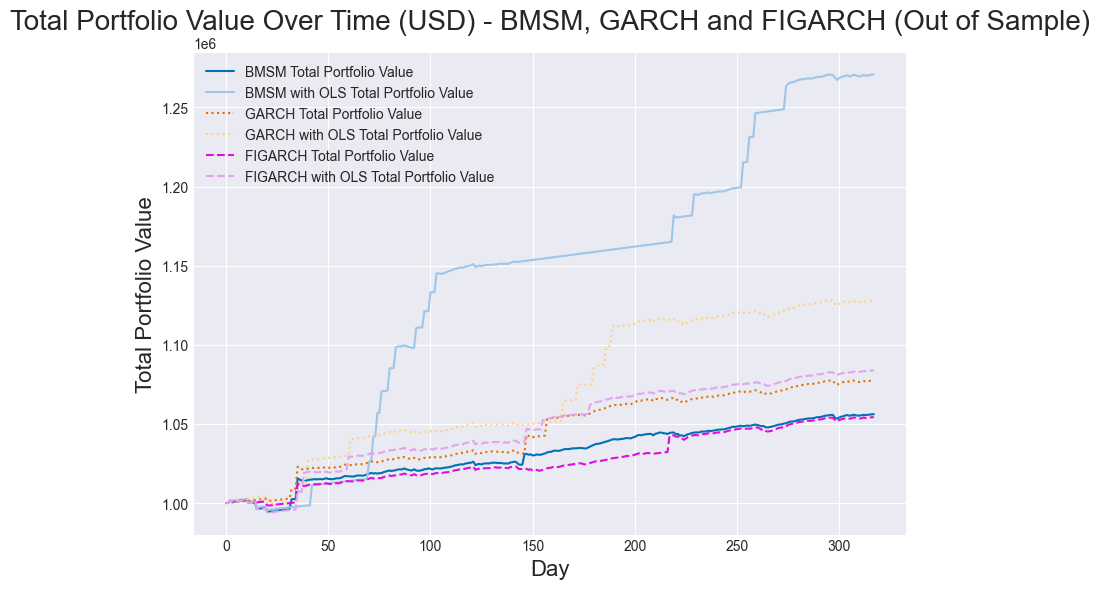

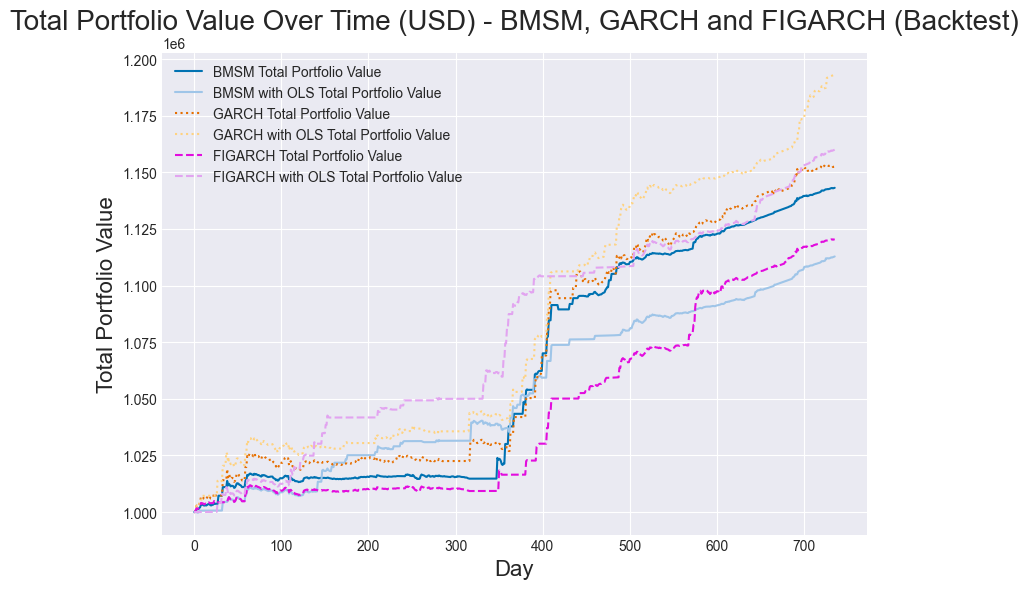

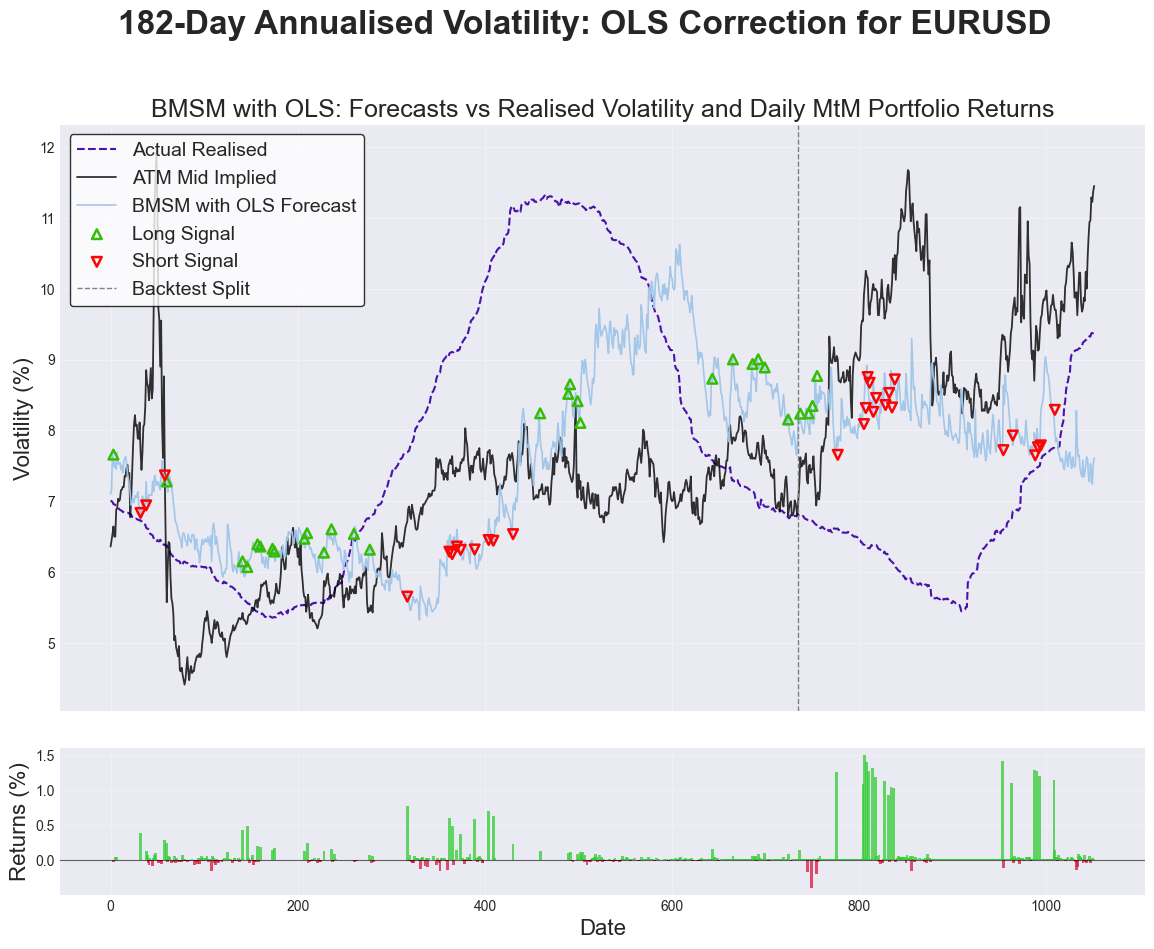

In [6]:
strategy_3 = Compare_Trading_Strategies(
    return_series=daily_log_returns_3, 
    realised_variance_series=realised_variance_3,
    atm_implied_vol_data=implied_vol_data_3,
    vol_smile_data=vol_smile_data_3,
    train_size=train_size,
    ticker=TICKER,
    initial_capital_domestic=IC_USD,
    notional_base=NOTIONAL_EUR,
    maximum_delta_difference=MAX_DELTA_DIFF,
    signal_lb=SIGNAL_LB,
    signal_ub=SIGNAL_UB,
    transaction_cost_indicator=TRANSACTION_COST_BOOL,
    transaction_costs_spot=TRANSACTION_COSTS_SPOT,
    transaction_costs_option=TRANSACTION_COSTS_OPTION,
    option_maturity=OPTION_MATURITY_3,
    forecast_horizon=H_3,
    spot_series=spot_curr_test_3,
    overnight_domestic_rate=overn_dom_r_test_3,
    overnight_foreign_rate=overn_for_r_test_3,
    domestic_rate=r_t_test_3,
    foreign_rate=r_b_test_3, 
    plots = False, 
    verbose=False, 
    sort_hyperparams_by=HYPERPARAM_SORT, 
    garch_1_2_indicator=GARCH_1_2_INDICATOR, 
    kbar=k_bar_MSM,
    b=b_MSM,
    gamma_kbar=gamma_kbar_MSM,
    convert_USD=CONVERT_USD_INDICATOR, 
    M = M, 
    long_thresholds=long_threshs,
    short_thresholds=short_threshs,
    sig_multipliers=sig_multipliers)

df_3 = strategy_3.compare_strategies(verbose = False)

In [6]:
strategy_3 = Compare_Trading_Strategies(
    return_series=daily_log_returns_3, 
    realised_variance_series=realised_variance_3,
    atm_implied_vol_data=implied_vol_data_3,
    vol_smile_data=vol_smile_data_3,
    train_size=train_size,
    ticker=TICKER,
    initial_capital_domestic=IC_USD,
    notional_base=NOTIONAL_EUR,
    maximum_delta_difference=MAX_DELTA_DIFF,
    signal_lb=SIGNAL_LB,
    signal_ub=SIGNAL_UB,
    transaction_cost_indicator=TRANSACTION_COST_BOOL,
    transaction_costs_spot=TRANSACTION_COSTS_SPOT,
    transaction_costs_option=TRANSACTION_COSTS_OPTION,
    option_maturity=OPTION_MATURITY_3,
    forecast_horizon=H_3,
    spot_series=spot_curr_test_3,
    overnight_domestic_rate=overn_dom_r_test_3,
    overnight_foreign_rate=overn_for_r_test_3,
    domestic_rate=r_t_test_3,
    foreign_rate=r_b_test_3, 
    plots = False, 
    verbose=False, 
    sort_hyperparams_by=HYPERPARAM_SORT, 
    garch_1_2_indicator=GARCH_1_2_INDICATOR, 
    kbar=k_bar_MSM,
    b=b_MSM,
    gamma_kbar=gamma_kbar_MSM,
    convert_USD=CONVERT_USD_INDICATOR, 
    M = M, 
    long_thresholds=long_threshs,
    short_thresholds=short_threshs,
    sig_multipliers=sig_multipliers)

strategy_3.prepare_universal_series()
strategy_3.get_BMSM_hyperparams_and_run_strategy(False)

Estimated parameters: m0=1.210864e+00, sigma_bar=4.854110e-01
Final log-likelihood: -8.041643e+02
Estimated parameters: m0=1.199194e+00, sigma_bar=4.851642e-01
Final log-likelihood: -1.292050e+03


[I 2025-09-07 16:55:50,590] A new study created in memory with name: no-name-12543455-478a-4c64-937e-c0373a5e2773
[I 2025-09-07 16:55:51,244] Trial 0 finished with value: 1.7054091048109372 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.7054091048109372.
[I 2025-09-07 16:55:51,954] Trial 1 finished with value: 1.546317209049575 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 1.7054091048109372.
[I 2025-09-07 16:55:52,582] Trial 2 finished with value: 2.0065782246189343 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 2 with value: 2.0065782246189343.
[I 2025-09-07 16:55:53,213] Trial 3 finished with value: 0.9677269836298715 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 2 with value: 2.0065782246189343.
[I 2025-09-07 16:55:53,93

In [7]:
sigma_bt = strategy_3.atm_mid_implied_vol_backtest
d_sigma_bt = np.diff(sigma_bt)

sigma_oos = strategy_3.atm_mid_implied_vol_oos
d_sigma_oos = np.diff(sigma_oos)

In [8]:
option_positions_bt = strategy_3.trading_summary_bmsm_bt['Option Positions'][1:]
option_positions_oos = strategy_3.trading_summary_bmsm_oos['Option Positions'][1:]
total_positions = np.hstack((option_positions_bt[:-1], option_positions_oos[:-1]))

term1_bt = strategy_3.vega_bmsm_bt_ols[1:-1] * d_sigma_bt * option_positions_bt[:-1]
term1_oos = strategy_3.vega_bmsm_oos_ols[1:-1] * d_sigma_oos * option_positions_oos[:-1]

term2_bt = 0.5 * strategy_3.gamma_bmsm_bt_ols[1:] * (strategy_3.spot_price_backtest **2) * (strategy_3.forecasts_bmsm_backtest_ols - strategy_3.atm_mid_implied_vol_backtest **2) #* option_positions_bt #* dt
term2_oos = 0.5 * strategy_3.gamma_bmsm_oos_ols[1:] * (strategy_3.spot_price_oos **2) * (strategy_3.forecasts_bmsm_oos_ols - strategy_3.atm_mid_implied_vol_oos **2) #* option_positions_oos #* dt

term1 = np.hstack((term1_bt, term1_oos))
term2 = np.hstack((term2_bt[:-1], term2_oos[:-1])) 

In [9]:
actual_direction_bt = np.sign(strategy_3.true_var_series[:len(strategy_3.atm_mid_implied_vol_backtest)] - strategy_3.atm_mid_implied_vol_backtest**2)
actual_direction_oos = np.sign(strategy_3.true_var_series[len(strategy_3.atm_mid_implied_vol_backtest):] - strategy_3.atm_mid_implied_vol_oos**2)
actual_direction = np.hstack((actual_direction_bt[:-1], actual_direction_oos[:-1]))

In [10]:
dt = 1/252
term2_bt = 0.5 * strategy_3.gamma_bmsm_bt_ols[1:] * (strategy_3.spot_price_backtest **2) * (strategy_3.forecasts_bmsm_backtest_ols - strategy_3.atm_mid_implied_vol_backtest **2) * option_positions_bt * dt
term2_oos = 0.5 * strategy_3.gamma_bmsm_oos_ols[1:] * (strategy_3.spot_price_oos **2) * (strategy_3.forecasts_bmsm_oos_ols - strategy_3.atm_mid_implied_vol_oos **2) * option_positions_oos * dt
term2 = np.hstack((term2_bt[:-1], term2_oos[:-1]))

for i in range(len(term2)):
    if total_positions[i] != actual_direction[i]:
        term2[i] *= -1

(array([-10000.,  -5000.,      0.,   5000.,  10000.,  15000.,  20000.,
         25000.,  30000.]),
 [Text(0, -10000.0, '−10000'),
  Text(0, -5000.0, '−5000'),
  Text(0, 0.0, '0'),
  Text(0, 5000.0, '5000'),
  Text(0, 10000.0, '10000'),
  Text(0, 15000.0, '15000'),
  Text(0, 20000.0, '20000'),
  Text(0, 25000.0, '25000'),
  Text(0, 30000.0, '30000')])

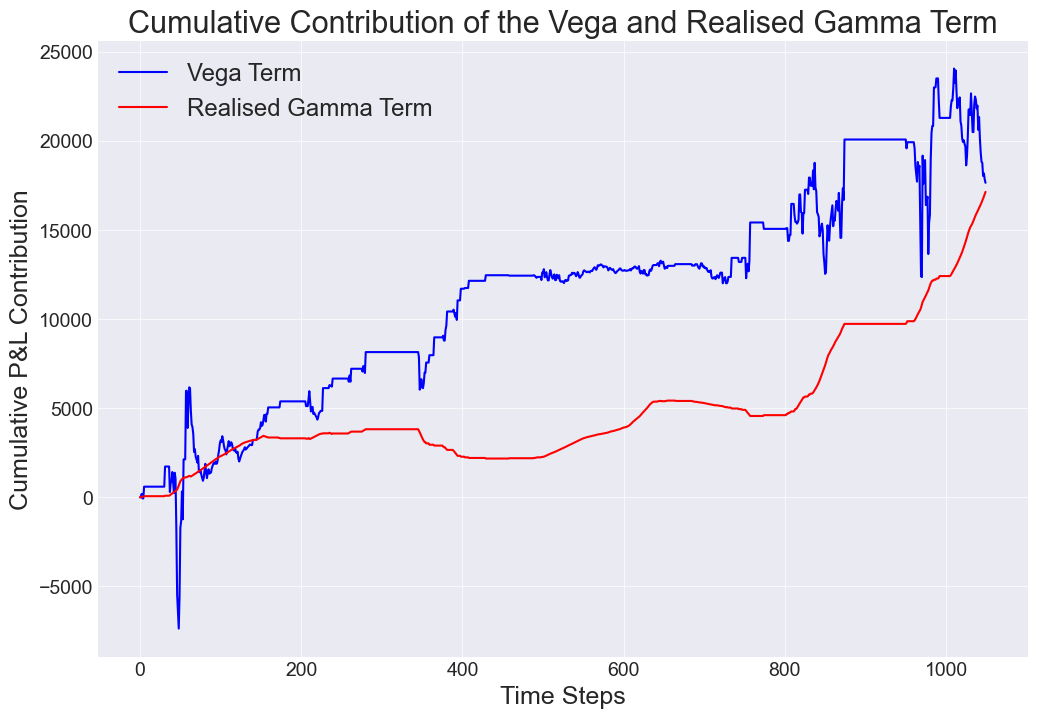

In [13]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 8))
plt.plot(term1.cumsum(), label="Vega Term", color = 'b')
plt.plot(term2.cumsum(), label="Realised Gamma Term", color = 'r')
plt.title("Cumulative Contribution of the Vega and Realised Gamma Term", fontsize=22)
plt.legend(fontsize='xx-large')
plt.grid(True, linestyle='-', alpha=0.7)
plt.xlabel("Time Steps", fontsize=18)
#plt.ylabel(r"$\nu^i_t \, d\tilde{\sigma}_t^i$", fontsize=18)
plt.ylabel("Cumulative P&L Contribution", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

(array([-6000., -4000., -2000.,     0.,  2000.,  4000.,  6000.,  8000.]),
 [Text(0, -6000.0, '−6000'),
  Text(0, -4000.0, '−4000'),
  Text(0, -2000.0, '−2000'),
  Text(0, 0.0, '0'),
  Text(0, 2000.0, '2000'),
  Text(0, 4000.0, '4000'),
  Text(0, 6000.0, '6000'),
  Text(0, 8000.0, '8000')])

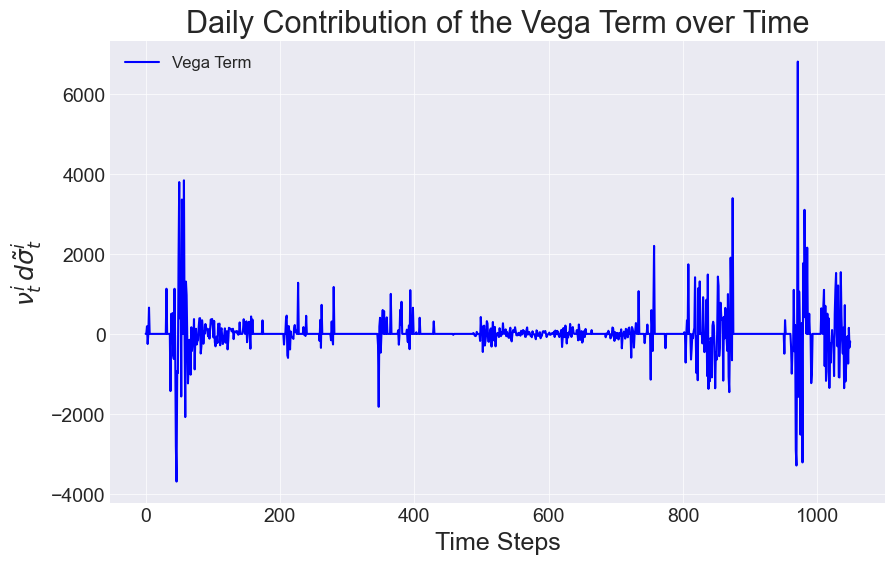

In [225]:
plt.figure(figsize=(10, 6))
plt.plot(term1, label="Vega Term", color = 'b')
#plt.plot(term2, label="Gamma Term")
plt.title("Daily Contribution of the Vega Term over Time", fontsize=22)
plt.legend(fontsize='large')
plt.grid(True, linestyle='-', alpha=0.7)
plt.xlabel("Time Steps", fontsize=18)
plt.ylabel(r"$\nu^i_t \, d\tilde{\sigma}_t^i$", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_37018/648594058.py:4: RuntimeWarning: invalid value encountered in divide
  vega = np.hstack((strategy_3.vega_bmsm_bt_ols, strategy_3.vega_bmsm_oos_ols)) / np.hstack((strategy_3.trading_summary_bmsm_bt_ols['Notional Adjusted'], strategy_3.trading_summary_bmsm_oos_ols['Notional Adjusted']))
/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_37018/648594058.py:5: RuntimeWarning: invalid value encountered in divide
  gamma = np.hstack((strategy_3.gamma_bmsm_bt_ols, strategy_3.gamma_bmsm_oos_ols)) / np.hstack((strategy_3.trading_summary_bmsm_bt_ols['Notional Adjusted'], strategy_3.trading_summary_bmsm_oos_ols['Notional Adjusted']))


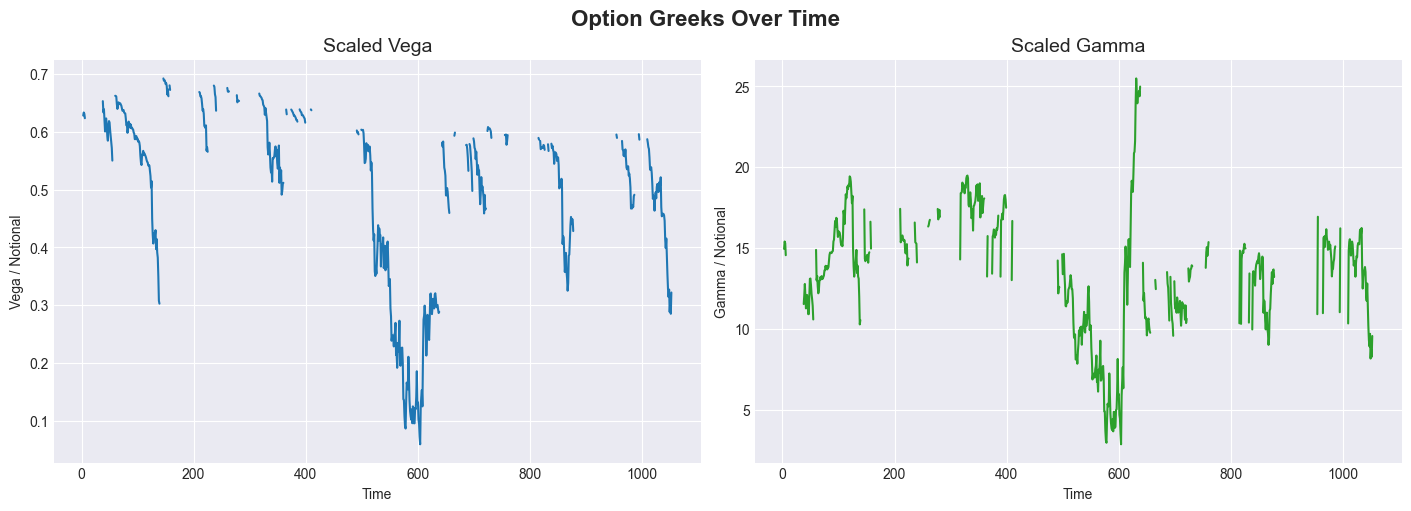

In [104]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

vega = np.hstack((strategy_3.vega_bmsm_bt_ols, strategy_3.vega_bmsm_oos_ols)) / np.hstack((strategy_3.trading_summary_bmsm_bt_ols['Notional Adjusted'], strategy_3.trading_summary_bmsm_oos_ols['Notional Adjusted']))
gamma = np.hstack((strategy_3.gamma_bmsm_bt_ols, strategy_3.gamma_bmsm_oos_ols)) / np.hstack((strategy_3.trading_summary_bmsm_bt_ols['Notional Adjusted'], strategy_3.trading_summary_bmsm_oos_ols['Notional Adjusted']))

axes[0].plot(vega, color="tab:blue", lw=1.5)
axes[0].set_title("Scaled Vega", fontsize=14)
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Vega / Notional")

axes[1].plot(gamma, color="tab:green", lw=1.5)
axes[1].set_title("Scaled Gamma", fontsize=14)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Gamma / Notional")

plt.suptitle("Option Greeks Over Time", fontsize=16, weight="bold")
plt.show()

In [15]:
df_3

,long_threshold,short_threshold,signal_multiplier,sharpe_ratio (USD),max_drawdown (USD),calmar_ratio (USD),cagr (USD),Precision (all),Precision (active),Win/loss ratio (all),Win/loss ratio (active),Avg win (all),Avg win (active),Avg loss (all),Avg loss (active),Non-active share,Total trades
BMSM Backtest,1.10,0.90,1.00,2.55,-0.37,10.25,4.69%,0.38,0.48,3.63,3.27,0.06%,0.06%,-0.02%,-0.02%,0.20,34.00
BMSM Out of Sample,1.10,0.90,1.00,0.45,-0.72,0.98,4.43%,0.52,0.56,0.95,0.90,0.04%,0.04%,-0.04%,-0.04%,0.07,7.00
BMSM with OLS Backtest,1.27,0.73,1.00,2.43,-0.47,6.12,3.73%,0.30,0.50,3.17,2.71,0.06%,0.06%,-0.02%,-0.02%,0.41,37.00
BMSM with OLS Out of Sample,1.27,0.73,1.00,3.53,-0.69,22.24,20.92%,0.27,0.61,7.25,5.32,0.26%,0.26%,-0.04%,-0.05%,0.55,21.00
GARCH Backtest,1.27,0.93,1.00,2.13,-0.72,5.61,4.98%,0.42,0.51,2.00,1.86,0.08%,0.08%,-0.04%,-0.04%,0.16,24.00
GARCH Out of Sample,1.27,0.93,1.00,1.17,-0.29,7.76,6.08%,0.50,0.56,1.28,1.23,0.05%,0.05%,-0.04%,-0.04%,0.12,5.00
GARCH with OLS Backtest,1.27,0.79,1.00,2.79,-0.72,7.30,6.24%,0.32,0.50,3.19,2.74,0.10%,0.10%,-0.03%,-0.04%,0.36,40.00
GARCH with OLS Out of Sample,1.27,0.79,1.00,2.05,-0.56,10.59,10.01%,0.41,0.56,2.16,1.95,0.10%,0.10%,-0.04%,-0.05%,0.27,11.00
FIGARCH Backtest,1.26,0.98,1.00,2.41,-0.42,7.31,3.97%,0.37,0.48,2.86,2.64,0.06%,0.06%,-0.02%,-0.02%,0.24,25.00
FIGARCH Out of Sample,1.26,0.98,1.00,0.37,-0.35,1.60,4.28%,0.53,0.58,0.87,0.84,0.03%,0.03%,-0.04%,-0.04%,0.08,5.00


In [33]:
df_3.data.to_csv("USDEUR_Strategy_H_182_T_6MO.csv", index=True)

In [34]:
strategy_3.model_bmsm_oos.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.144
Model:                            OLS   Adj. R-squared:                  0.142
Method:                 Least Squares   F-statistic:                     18.52
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           6.32e-15
Time:                        11:52:49   Log-Likelihood:                 453.05
No. Observations:                1786   AIC:                            -896.1
Df Residuals:                    1781   BIC:                            -868.7
Df Model:                           4                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0017      0.012     -0.133      0.894      -0.026       0.023
x1             0.0541      0.030      1.830      0.067      -0.004       0.112
x2            -0.0872      0.028     -3.115      0.002      -0.142      -0.032
x3            -0.0540      0.014     -3.821      0.000      -0.082      -0.026
x4            -0.0444      0.015     -2.974      0.003      -0.074      -0.015
==============================================================================
Omnibus:                       40.696   Durbin-Watson:                   0.013
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               24.444
Skew:                          -0.127   Prob(JB):                     4.92e-06
Kurtosis:                       2.486   Cond. No.                         7.93
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 7 lags and without small sample correction
"""

In [35]:
strategy_3.model_garch_oos.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.139
Model:                            OLS   Adj. R-squared:                  0.138
Method:                 Least Squares   F-statistic:                     15.10
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           1.05e-09
Time:                        11:52:52   Log-Likelihood:                 499.93
No. Observations:                1786   AIC:                            -991.9
Df Residuals:                    1782   BIC:                            -969.9
Df Model:                           3                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0475      0.012     -3.921      0.000      -0.071      -0.024
x1             0.1038      0.017      5.980      0.000       0.070       0.138
x2            -0.0437      0.014     -3.043      0.002      -0.072      -0.016
x3            -0.0472      0.016     -2.947      0.003      -0.079      -0.016
==============================================================================
Omnibus:                       48.865   Durbin-Watson:                   0.024
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               26.125
Skew:                          -0.096   Prob(JB):                     2.12e-06
Kurtosis:                       2.439   Cond. No.                         2.94
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 7 lags and without small sample correction
"""

In [36]:
strategy_3.model_figarch_oos.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.137
Model:                            OLS   Adj. R-squared:                  0.136
Method:                 Least Squares   F-statistic:                     15.30
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           7.92e-10
Time:                        11:52:56   Log-Likelihood:                 411.82
No. Observations:                1786   AIC:                            -815.6
Df Residuals:                    1782   BIC:                            -793.7
Df Model:                           3                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0346      0.013     -2.723      0.006      -0.059      -0.010
x1            -0.0290      0.008     -3.631      0.000      -0.045      -0.013
x2            -0.0504      0.015     -3.405      0.001      -0.079      -0.021
x3            -0.0383      0.014     -2.720      0.007      -0.066      -0.011
==============================================================================
Omnibus:                       62.863   Durbin-Watson:                   0.027
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               28.737
Skew:                          -0.001   Prob(JB):                     5.75e-07
Kurtosis:                       2.379   Cond. No.                         2.56
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 7 lags and without small sample correction
"""

# H=364, T=1Y

In [10]:
OPTION_MATURITY_4 = 1
H_4 = 364

vol_smile_data_4 = pd.read_csv("eurusd_vol_smile_1y_extra.csv").set_index("CalculationDate")
implied_vol_data_4 = pd.DataFrame({
    'Exchange Date': vol_smile_data_4.index, 
    "Bid": vol_smile_data_4['ATM'], 
    "Ask": vol_smile_data_4['ATM'],
    "BidNet": vol_smile_data_4['ATM']})
Data_clean_4 = Clean_Implied_Vols_EUR_with_smile(data=implied_vol_data_4, 
                                start_date=start_date, 
                                end_date=end_date, 
                                align_df1=realised_variance_eurusd, 
                                align_df2=daily_log_returns_eurusd, 
                                smile_df=vol_smile_data_4)
implied_vol_data_4, realised_variance_4, daily_log_returns_4, vol_smile_data_4 = Data_clean_4.get_clean_data()

N_4 = len(daily_log_returns_4)
test_align_4 = daily_log_returns_4.iloc[N_4//2:-H_4]
spot_curr_test_4 = align_spots(spot_curr, test_align_4, start_date, end_date)

r_b_4 = pd.read_csv("estr_1y_compounded.csv").set_index("Date")
r_t_4 = pd.read_csv("/Users/alexvillamartin/Documents/MSc Diss/Code/SOFR_1y_compounded.csv").set_index("date")[['rate_pct']]

r_b_test_4, r_t_test_4, overn_dom_r_test_4, overn_for_r_test_4= sort_rates(r_b_4, r_t_4, overnight_domestic_rate, test_align_4, overnight_foreign_rate) 
r_b_test_4.ffill(inplace=True)

Estimated parameters: m0=1.210864e+00, sigma_bar=4.854110e-01
Final log-likelihood: -8.041643e+02
Estimated parameters: m0=1.202056e+00, sigma_bar=4.886992e-01
Final log-likelihood: -1.192038e+03


[I 2025-09-03 17:16:04,327] A new study created in memory with name: no-name-4d9962a8-6629-4032-a250-af4af8a3de5b
[I 2025-09-03 17:16:04,807] Trial 0 finished with value: 0.5927261135231217 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.5927261135231217.
[I 2025-09-03 17:16:05,332] Trial 1 finished with value: 1.839698387585723 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 1 with value: 1.839698387585723.
[I 2025-09-03 17:16:05,785] Trial 2 finished with value: 2.0454091004655726 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 2 with value: 2.0454091004655726.
[I 2025-09-03 17:16:06,213] Trial 3 finished with value: 0.7253824469986082 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 2 with value: 2.0454091004655726.
[I 2025-09-03 17:16:06,760

Estimated parameters: omega=0.0009705549253154421, alpha=0.0378, beta=0.9598
Estimated parameters: omega=0.005056556141756255, alpha=0.0377, beta=0.9448


[I 2025-09-03 17:23:01,744] A new study created in memory with name: no-name-ee9b620f-15c6-447d-bed3-91d4c3f73ccb
[I 2025-09-03 17:23:02,298] Trial 0 finished with value: -0.10043555707951345 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: -0.10043555707951345.
[I 2025-09-03 17:23:02,878] Trial 1 finished with value: 0.870857745031488 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 1 with value: 0.870857745031488.
[I 2025-09-03 17:23:03,429] Trial 2 finished with value: -0.08492705787531242 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 1 with value: 0.870857745031488.
[I 2025-09-03 17:23:03,982] Trial 3 finished with value: 0.36837420516206587 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 1 with value: 0.870857745031488.
/Users/alexvillamarti

Estimated parameters: omega=0.04783632598877084, d=0.2740, beta=0.2590
Final log-likelihood = 598.9679
Estimated parameters: omega=0.04162535252925603, d=0.2939, beta=0.2833
Final log-likelihood = 938.3661


[I 2025-09-03 17:31:43,834] A new study created in memory with name: no-name-bffa90b7-72c0-4d9b-9583-d342c2eee732
[I 2025-09-03 17:31:44,443] Trial 0 finished with value: -0.5038688098085772 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: -0.5038688098085772.
[I 2025-09-03 17:31:45,016] Trial 1 finished with value: 0.1550754195782617 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 1 with value: 0.1550754195782617.
[I 2025-09-03 17:31:45,564] Trial 2 finished with value: -0.03211695500337587 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 1 with value: 0.1550754195782617.
[I 2025-09-03 17:31:46,130] Trial 3 finished with value: 0.48964530262456496 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 3 with value: 0.48964530262456496.
[I 2025-09-03 17:3

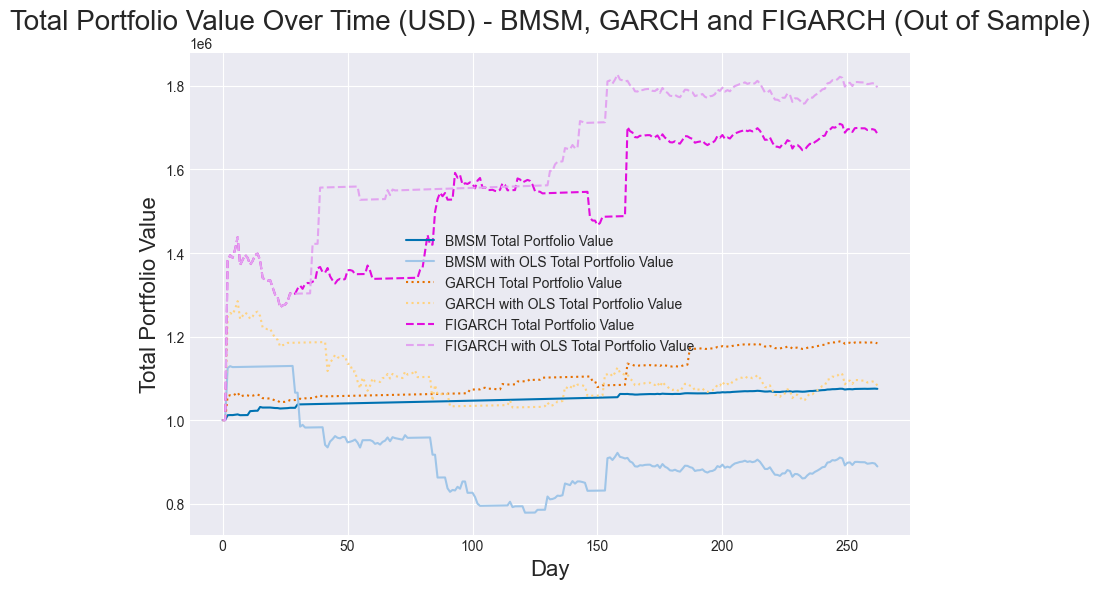

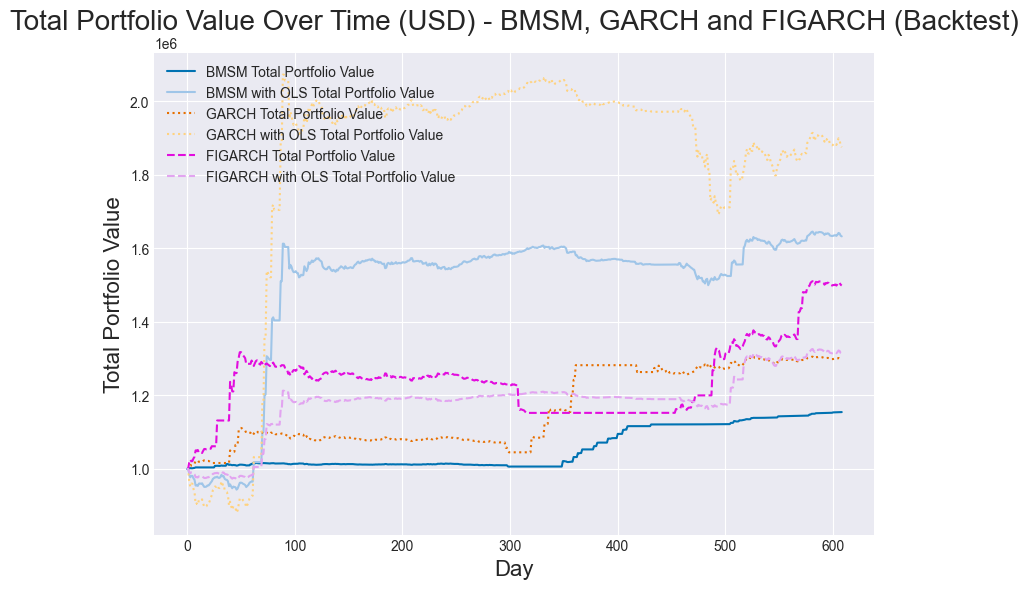

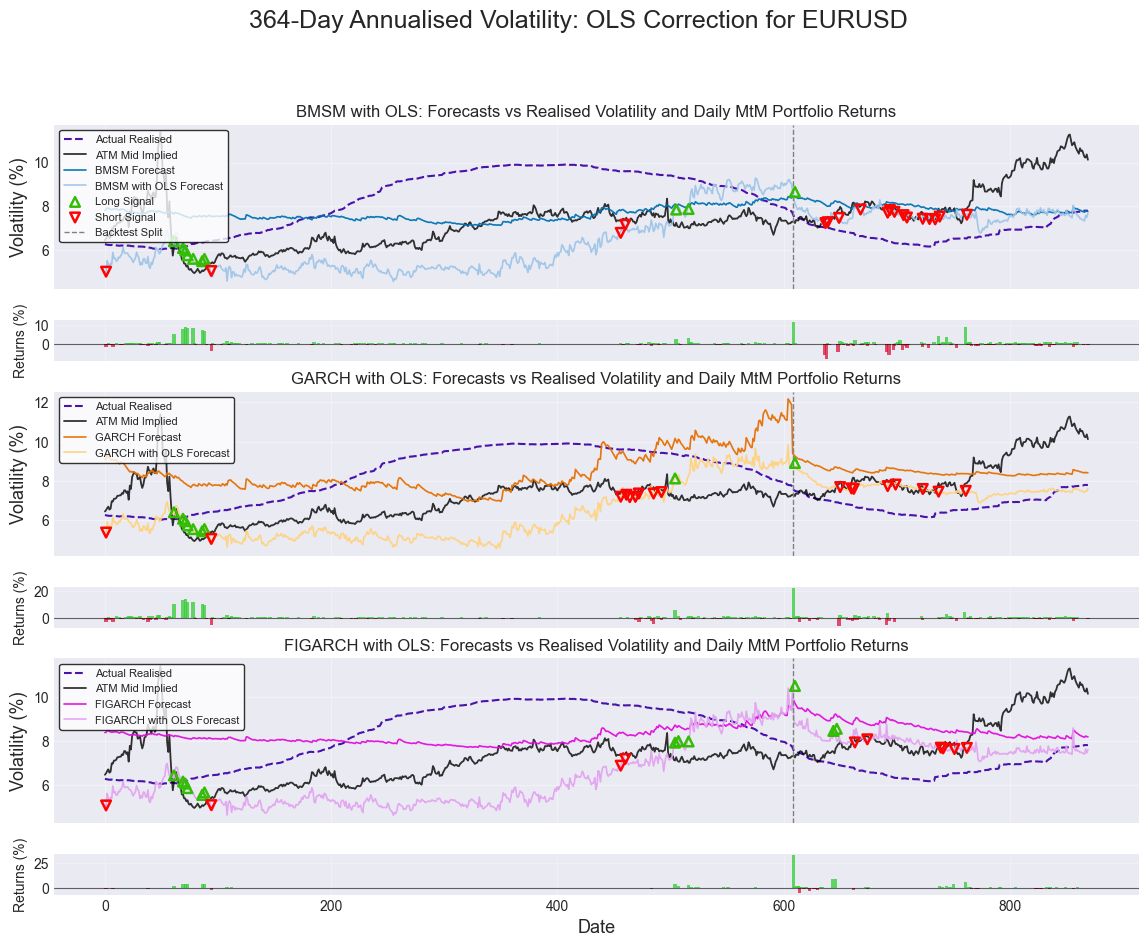

In [11]:
strategy_4 = Compare_Trading_Strategies(
    return_series=daily_log_returns_4, 
    realised_variance_series=realised_variance_4,
    atm_implied_vol_data=implied_vol_data_4,
    vol_smile_data=vol_smile_data_4,
    train_size=train_size,
    ticker=TICKER,
    initial_capital_domestic=IC_USD,
    notional_base=NOTIONAL_EUR,
    maximum_delta_difference=MAX_DELTA_DIFF,
    signal_lb=SIGNAL_LB,
    signal_ub=SIGNAL_UB,
    transaction_cost_indicator=TRANSACTION_COST_BOOL,
    transaction_costs_spot=TRANSACTION_COSTS_SPOT,
    transaction_costs_option=TRANSACTION_COSTS_OPTION,
    option_maturity=OPTION_MATURITY_4,
    forecast_horizon=H_4,
    spot_series=spot_curr_test_4,
    overnight_domestic_rate=overn_dom_r_test_4,
    overnight_foreign_rate=overn_for_r_test_4,
    domestic_rate=r_t_test_4,
    foreign_rate=r_b_test_4, 
    plots = False, 
    verbose=False, 
    sort_hyperparams_by=HYPERPARAM_SORT, 
    garch_1_2_indicator=GARCH_1_2_INDICATOR, 
    kbar=k_bar_MSM,
    b=b_MSM,
    gamma_kbar=gamma_kbar_MSM,
    convert_USD=CONVERT_USD_INDICATOR, 
    M = M, 
    long_thresholds=long_threshs,
    short_thresholds=short_threshs,
    sig_multipliers=sig_multipliers)

df_4 = strategy_4.compare_strategies(verbose = False)

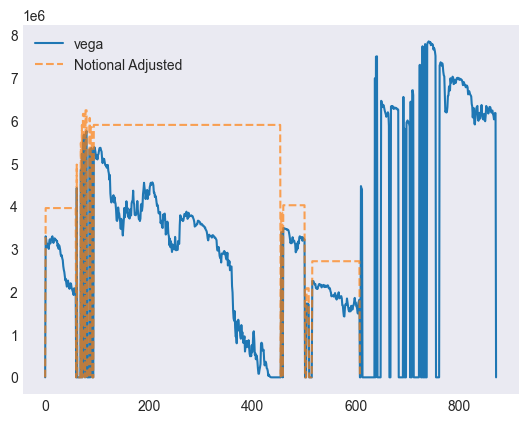

In [12]:
plt.plot(np.hstack((strategy_4.vega_bmsm_bt_ols,strategy_4.vega_bmsm_oos_ols)), label = 'vega')
plt.plot(strategy_4.trading_summary_bmsm_bt_ols['Notional Adjusted'], label = 'Notional Adjusted', linestyle = '--', alpha = 0.7)
plt.legend()

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_76676/3051198102.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(strategy_4.vega_bmsm_bt_ols / strategy_4.trading_summary_bmsm_bt_ols['Notional Adjusted'])


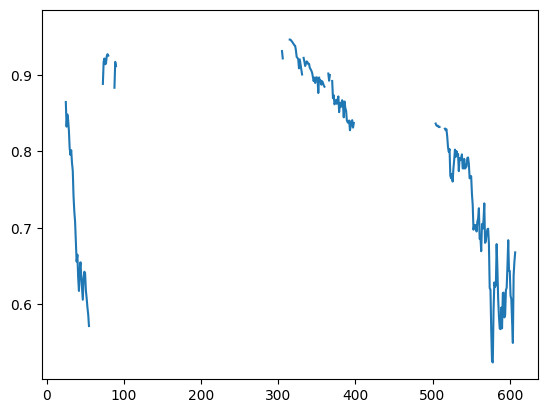

In [13]:
plt.plot(strategy_4.vega_bmsm_bt_ols / strategy_4.trading_summary_bmsm_bt_ols['Notional Adjusted'])

In [40]:
error_metrics_df_4 = strategy_4.get_statistical_error_metrics_for_all() # for H=30, T=30 options EURUSD

In [41]:
error_metrics_df_4

,Norm MSE,DM Test Stat MSE,DM p-value (one-sided) MSE,Norm MAE,DM Test Stat MAE,DM p-value (one-sided) MAE
BMSM,1.192970,NaN,NaN,1.070419,NaN,NaN
BMSM OLS,3.146594,0.926206,0.822702,1.550808,0.741232,0.770623
GARCH,1.565815,NaN,NaN,1.226633,NaN,NaN
GARCH OLS,2.741493,0.513369,0.696088,1.444832,0.259422,0.602315
FIGARCH,1.371375,NaN,NaN,1.171797,NaN,NaN
FIGARCH OLS,3.236759,0.714333,0.762393,1.602246,0.516291,0.697109


In [42]:
error_metrics_df_4.to_csv("USDEUR_Errors_H_364_T_1Y_OLS.csv")

In [176]:
df_4

,long_threshold,short_threshold,signal_multiplier,sharpe_ratio (USD),max_drawdown (USD),calmar_ratio (USD),cagr (USD),Precision (all),Precision (active),Win/loss ratio (all),Win/loss ratio (active),Avg win (all),Avg win (active),Avg loss (all),Avg loss (active),Non-active share,Total trades
BMSM Backtest,1.25,0.92,1.00,2.46,-0.99,5.68,6.13%,0.28,0.48,4.31,3.77,0.11%,0.11%,-0.03%,-0.03%,0.42,27.00
BMSM Out of Sample,1.25,0.92,1.00,1.79,-0.35,10.16,7.16%,0.24,0.48,2.78,2.59,0.10%,0.10%,-0.04%,-0.04%,0.51,5.00
BMSM with OLS Backtest,1.20,0.97,11.00,1.43,-7.01,2.85,22.49%,0.50,0.53,1.72,1.64,0.35%,0.35%,-0.21%,-0.22%,0.05,13.00
BMSM with OLS Out of Sample,1.20,0.97,11.00,-0.66,-31.10,-0.47,-10.66%,0.32,0.47,1.08,0.94,0.81%,0.81%,-0.75%,-0.87%,0.31,15.00
GARCH Backtest,1.27,0.97,3.00,1.45,-5.96,1.75,11.36%,0.36,0.45,2.20,2.07,0.28%,0.28%,-0.13%,-0.14%,0.22,16.00
GARCH Out of Sample,1.27,0.97,3.00,1.53,-2.30,5.60,17.54%,0.31,0.52,2.26,1.98,0.31%,0.31%,-0.14%,-0.16%,0.40,11.00
GARCH with OLS Backtest,1.18,0.98,13.00,1.14,-18.35,1.40,29.71%,0.50,0.53,1.47,1.39,0.57%,0.57%,-0.39%,-0.41%,0.06,17.00
GARCH with OLS Out of Sample,1.18,0.98,13.00,0.16,-19.82,0.22,7.88%,0.35,0.48,1.25,1.15,0.88%,0.88%,-0.70%,-0.76%,0.26,9.00
FIGARCH Backtest,1.25,0.97,20.00,1.46,-12.56,1.31,18.23%,0.31,0.45,2.28,2.13,0.49%,0.49%,-0.22%,-0.23%,0.31,17.00
FIGARCH Out of Sample,1.25,0.97,20.00,1.27,-11.68,4.01,64.94%,0.40,0.51,1.92,1.79,1.02%,1.02%,-0.53%,-0.57%,0.21,8.00


In [44]:
df_4.data.to_csv("USDEUR_Strategy_H_364_T_1Y.csv", index=True)

In [46]:
strategy_4.model_bmsm_oos.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.286
Model:                            OLS   Adj. R-squared:                  0.284
Method:                 Least Squares   F-statistic:                     30.13
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           3.97e-24
Time:                        12:59:55   Log-Likelihood:                 1227.5
No. Observations:                1477   AIC:                            -2445.
Df Residuals:                    1472   BIC:                            -2419.
Df Model:                           4                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0485      0.008     -6.362      0.000      -0.064      -0.034
x1             0.0116      0.016      0.703      0.482      -0.021       0.044
x2            -0.0634      0.016     -3.883      0.000      -0.095      -0.031
x3            -0.0178      0.011     -1.649      0.099      -0.039       0.003
x4            -0.0755      0.010     -7.419      0.000      -0.095      -0.056
==============================================================================
Omnibus:                       14.818   Durbin-Watson:                   0.023
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               14.695
Skew:                          -0.223   Prob(JB):                     0.000644
Kurtosis:                       2.801   Cond. No.                         8.08
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 7 lags and without small sample correction
"""

In [47]:
strategy_4.model_garch_oos.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.359
Method:                 Least Squares   F-statistic:                     50.52
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           4.44e-31
Time:                        13:00:04   Log-Likelihood:                 1299.2
No. Observations:                1477   AIC:                            -2590.
Df Residuals:                    1473   BIC:                            -2569.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1336      0.007    -18.458      0.000      -0.148      -0.119
x1             0.0439      0.006      6.977      0.000       0.032       0.056
x2            -0.0146      0.010     -1.458      0.145      -0.034       0.005
x3            -0.0836      0.010     -8.095      0.000      -0.104      -0.063
==============================================================================
Omnibus:                        2.234   Durbin-Watson:                   0.029
Prob(Omnibus):                  0.327   Jarque-Bera (JB):                2.289
Skew:                          -0.091   Prob(JB):                        0.318
Kurtosis:                       2.938   Cond. No.                         2.90
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 7 lags and without small sample correction
"""

In [48]:
strategy_4.model_figarch_oos.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.188
Model:                            OLS   Adj. R-squared:                  0.187
Method:                 Least Squares   F-statistic:                     13.05
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           2.07e-08
Time:                        13:00:09   Log-Likelihood:                 1089.9
No. Observations:                1477   AIC:                            -2172.
Df Residuals:                    1473   BIC:                            -2151.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1055      0.008    -12.667      0.000      -0.122      -0.089
x1            -0.0164      0.006     -2.832      0.005      -0.028      -0.005
x2            -0.0043      0.013     -0.329      0.742      -0.030       0.022
x3            -0.0526      0.012     -4.229      0.000      -0.077      -0.028
==============================================================================
Omnibus:                        9.665   Durbin-Watson:                   0.038
Prob(Omnibus):                  0.008   Jarque-Bera (JB):                8.892
Skew:                           0.145   Prob(JB):                       0.0117
Kurtosis:                       2.755   Cond. No.                         2.54
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 7 lags and without small sample correction
"""